In [1]:
# =============================================================================
# CELL 1 — SYNTHETIC REGISTRATION BENCHMARK
# =============================================================================

import os
import json
import math
import random
import numpy as np
import pandas as pd

from pathlib import Path

print("=" * 80)
print("SYNTHETIC GEOMETRIC REGISTRATION BENCHMARK")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Project paths
# -----------------------------------------------------------------------------

PROJECT_ROOT = r"D:\ISRO"

INTEGRATED_ROOT = os.path.join(
    PROJECT_ROOT,
    "Integrated_Multimodal_Siamese"
)

SYNTHETIC_ROOT = os.path.join(
    INTEGRATED_ROOT,
    "pairs",
    "expanded_synthetic_benchmark"
)

REGISTRATION_ROOT = os.path.join(
    PROJECT_ROOT,
    "Synthetic_Registration_Benchmark"
)

PAIRS_DIR = os.path.join(
    REGISTRATION_ROOT,
    "pairs"
)

RESULTS_DIR = os.path.join(
    REGISTRATION_ROOT,
    "results"
)

MODELS_DIR = os.path.join(
    REGISTRATION_ROOT,
    "models"
)

FIGURES_DIR = os.path.join(
    REGISTRATION_ROOT,
    "figures"
)

LOGS_DIR = os.path.join(
    REGISTRATION_ROOT,
    "logs"
)

for directory in [
    REGISTRATION_ROOT,
    PAIRS_DIR,
    RESULTS_DIR,
    MODELS_DIR,
    FIGURES_DIR,
    LOGS_DIR,
]:
    os.makedirs(
        directory,
        exist_ok=True
    )

# -----------------------------------------------------------------------------
# 2. Input benchmark
# -----------------------------------------------------------------------------

SYNTHETIC_BENCHMARK_PATH = os.path.join(
    SYNTHETIC_ROOT,
    "three_modal_expanded_robustness_benchmark.npz"
)

SYNTHETIC_METADATA_PATH = os.path.join(
    SYNTHETIC_ROOT,
    "expanded_benchmark_metadata.csv"
)

SPLIT_DIR = os.path.join(
    SYNTHETIC_ROOT,
    "splits"
)

TRAIN_SPLIT_PATH = os.path.join(
    SPLIT_DIR,
    "train_synthetic_data.npz"
)

VALIDATION_SPLIT_PATH = os.path.join(
    SPLIT_DIR,
    "validation_synthetic_data.npz"
)

TEST_SPLIT_PATH = os.path.join(
    SPLIT_DIR,
    "test_synthetic_data.npz"
)

# -----------------------------------------------------------------------------
# 3. Reproducibility
# -----------------------------------------------------------------------------

RANDOM_SEED = 20260906

random.seed(
    RANDOM_SEED
)

np.random.seed(
    RANDOM_SEED
)

RNG = np.random.default_rng(
    RANDOM_SEED
)

# -----------------------------------------------------------------------------
# 4. Registration configuration
# -----------------------------------------------------------------------------

EMBED_DIM = 256

# Number of synthetic spatial correspondence points
POINTS_PER_CASE = 100

# Coordinate extent of the synthetic image plane.
# Units are arbitrary image-coordinate units.
IMAGE_WIDTH = 1000.0
IMAGE_HEIGHT = 1000.0

# -----------------------------------------------------------------------------
# 5. Geometric transformation ranges
# -----------------------------------------------------------------------------

ROTATION_RANGES_DEG = {
    "easy": (-5.0, 5.0),
    "moderate": (-15.0, 15.0),
    "difficult": (-30.0, 30.0),
    "extreme": (-45.0, 45.0),
}

SCALE_RANGES = {
    "easy": (0.95, 1.05),
    "moderate": (0.85, 1.15),
    "difficult": (0.70, 1.30),
    "extreme": (0.50, 1.50),
}

TRANSLATION_RANGES = {
    "easy": 25.0,
    "moderate": 75.0,
    "difficult": 150.0,
    "extreme": 250.0,
}

# -----------------------------------------------------------------------------
# 6. Localization-noise levels
# -----------------------------------------------------------------------------

LOCALIZATION_NOISE_STD = {
    "none": 0.0,
    "low": 0.5,
    "moderate": 2.0,
    "high": 5.0,
    "severe": 10.0,
}

# -----------------------------------------------------------------------------
# 7. Outlier contamination levels
# -----------------------------------------------------------------------------

OUTLIER_RATIOS = {
    "clean": 0.00,
    "low": 0.10,
    "moderate": 0.20,
    "high": 0.30,
    "severe": 0.40,
    "extreme": 0.50,
    "very_extreme": 0.60,
}

# -----------------------------------------------------------------------------
# 8. Partial-overlap levels
# -----------------------------------------------------------------------------

OVERLAP_RATIOS = {
    "full": 1.00,
    "high": 0.80,
    "moderate": 0.60,
    "low": 0.40,
}

# -----------------------------------------------------------------------------
# 9. RANSAC configuration
# -----------------------------------------------------------------------------

RANSAC_REPROJ_THRESHOLD = {
    "easy": 3.0,
    "moderate": 5.0,
    "difficult": 8.0,
    "extreme": 12.0,
}

RANSAC_MAX_TRIALS = 5000

RANSAC_CONFIDENCE = 0.995

# Minimum number of points required for a similarity transform.
MIN_REQUIRED_POINTS = 2

# -----------------------------------------------------------------------------
# 10. Registration success criteria
#
# These thresholds are fixed BEFORE evaluating the benchmark.
# -----------------------------------------------------------------------------

SUCCESS_MAX_RMSE = 10.0

SUCCESS_MAX_ROTATION_ERROR_DEG = 3.0

SUCCESS_MAX_SCALE_ERROR = 0.05

SUCCESS_MAX_TRANSLATION_ERROR = 15.0

SUCCESS_MIN_INLIER_RATIO = 0.50

# -----------------------------------------------------------------------------
# 11. Planned benchmark dimensions
# -----------------------------------------------------------------------------

GEOMETRIC_LEVELS = [
    "easy",
    "moderate",
    "difficult",
    "extreme",
]

NOISE_LEVELS = [
    "none",
    "low",
    "moderate",
    "high",
    "severe",
]

OUTLIER_LEVELS = [
    "clean",
    "low",
    "moderate",
    "high",
    "severe",
    "extreme",
    "very_extreme",
]

OVERLAP_LEVELS = [
    "full",
    "high",
    "moderate",
    "low",
]

# -----------------------------------------------------------------------------
# 12. Verify input files
# -----------------------------------------------------------------------------

required_files = {
    "expanded benchmark":
        SYNTHETIC_BENCHMARK_PATH,

    "expanded metadata":
        SYNTHETIC_METADATA_PATH,

    "train split":
        TRAIN_SPLIT_PATH,

    "validation split":
        VALIDATION_SPLIT_PATH,

    "test split":
        TEST_SPLIT_PATH,
}

missing_files = []

for label, path in required_files.items():

    if not os.path.exists(path):
        missing_files.append(
            f"{label}: {path}"
        )

if missing_files:

    print()
    print("[ERROR] Required benchmark files are missing:")

    for item in missing_files:
        print(
            f"  - {item}"
        )

    raise FileNotFoundError(
        "Registration benchmark cannot start because "
        "required input files are missing."
    )

# -----------------------------------------------------------------------------
# 13. Load benchmark metadata
# -----------------------------------------------------------------------------

BENCHMARK_METADATA = pd.read_csv(
    SYNTHETIC_METADATA_PATH
)

# -----------------------------------------------------------------------------
# 14. Basic benchmark validation
# -----------------------------------------------------------------------------

with np.load(
    SYNTHETIC_BENCHMARK_PATH,
    allow_pickle=True
) as benchmark:

    BENCHMARK_KEYS = list(
        benchmark.keys()
    )

    REQUIRED_KEYS = [
        "iirs",
        "ohrc",
        "tmc2",
        "wrong_tmc2",
        "hard_negative_tmc2",
        "anchor_index",
        "scenario_index",
        "matched_label",
    ]

    missing_keys = [
        key
        for key in REQUIRED_KEYS
        if key not in BENCHMARK_KEYS
    ]

    if missing_keys:

        raise KeyError(
            "Synthetic benchmark is missing keys: "
            + ", ".join(missing_keys)
        )

    BENCHMARK_N = len(
        benchmark["iirs"]
    )

    BENCHMARK_DIM = benchmark[
        "iirs"
    ].shape[1]

# -----------------------------------------------------------------------------
# 15. Validation of dimensions
# -----------------------------------------------------------------------------

if BENCHMARK_DIM != EMBED_DIM:

    raise ValueError(
        f"Expected {EMBED_DIM}-D embeddings, "
        f"found {BENCHMARK_DIM}-D."
    )

if BENCHMARK_N != 13600:

    raise ValueError(
        f"Expected 13,600 expanded examples, "
        f"found {BENCHMARK_N}."
    )

if len(BENCHMARK_METADATA) != BENCHMARK_N:

    raise ValueError(
        "Metadata row count does not match benchmark "
        "example count."
    )

# -----------------------------------------------------------------------------
# 16. Save configuration
# -----------------------------------------------------------------------------

CONFIG_PATH = os.path.join(
    LOGS_DIR,
    "registration_benchmark_configuration.json"
)

CONFIG = {
    "random_seed":
        RANDOM_SEED,

    "embedding_dimension":
        EMBED_DIM,

    "points_per_case":
        POINTS_PER_CASE,

    "image_width":
        IMAGE_WIDTH,

    "image_height":
        IMAGE_HEIGHT,

    "rotation_ranges_deg":
        ROTATION_RANGES_DEG,

    "scale_ranges":
        SCALE_RANGES,

    "translation_ranges":
        TRANSLATION_RANGES,

    "localization_noise_std":
        LOCALIZATION_NOISE_STD,

    "outlier_ratios":
        OUTLIER_RATIOS,

    "overlap_ratios":
        OVERLAP_RATIOS,

    "ransac_reprojection_threshold":
        RANSAC_REPROJ_THRESHOLD,

    "ransac_max_trials":
        RANSAC_MAX_TRIALS,

    "ransac_confidence":
        RANSAC_CONFIDENCE,

    "success_criteria": {
        "max_rmse":
            SUCCESS_MAX_RMSE,

        "max_rotation_error_deg":
            SUCCESS_MAX_ROTATION_ERROR_DEG,

        "max_scale_error":
            SUCCESS_MAX_SCALE_ERROR,

        "max_translation_error":
            SUCCESS_MAX_TRANSLATION_ERROR,

        "min_inlier_ratio":
            SUCCESS_MIN_INLIER_RATIO,
    },

    "benchmark_input":
        SYNTHETIC_BENCHMARK_PATH,

    "metadata_input":
        SYNTHETIC_METADATA_PATH,

    "methodological_note":
        "Synthetic geometric registration benchmark using "
        "controlled correspondence points. It is a "
        "downstream simulation and does not constitute "
        "real geographic registration validation."
}

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        CONFIG,
        f,
        indent=2
    )

# -----------------------------------------------------------------------------
# 17. Final Cell 1 report
# -----------------------------------------------------------------------------

print()
print("=" * 80)
print("REGISTRATION BENCHMARK CONFIGURATION READY")
print("=" * 80)

print(
    f"Project root              : {PROJECT_ROOT}"
)

print(
    f"Registration root         : {REGISTRATION_ROOT}"
)

print(
    f"Benchmark examples        : {BENCHMARK_N}"
)

print(
    f"Embedding dimension       : {BENCHMARK_DIM}"
)

print(
    f"Points per registration   : {POINTS_PER_CASE}"
)

print()

print(
    "Geometric difficulty:"
)

for level in GEOMETRIC_LEVELS:

    print(
        f"  {level:10s} | "
        f"rotation {ROTATION_RANGES_DEG[level]} deg | "
        f"scale {SCALE_RANGES[level]} | "
        f"translation ±{TRANSLATION_RANGES[level]}"
    )

print()

print(
    "Localization noise:"
)

for level in NOISE_LEVELS:

    print(
        f"  {level:10s} | "
        f"σ = {LOCALIZATION_NOISE_STD[level]}"
    )

print()

print(
    "Outlier contamination:"
)

for level in OUTLIER_LEVELS:

    print(
        f"  {level:12s} | "
        f"{OUTLIER_RATIOS[level] * 100:.0f}%"
    )

print()

print(
    "Partial overlap:"
)

for level in OVERLAP_LEVELS:

    print(
        f"  {level:10s} | "
        f"{OVERLAP_RATIOS[level] * 100:.0f}%"
    )

print()

print(
    "Registration success criteria:"
)

print(
    f"  RMSE                  ≤ {SUCCESS_MAX_RMSE}"
)

print(
    f"  Rotation error        ≤ "
    f"{SUCCESS_MAX_ROTATION_ERROR_DEG} deg"
)

print(
    f"  Scale error           ≤ "
    f"{SUCCESS_MAX_SCALE_ERROR}"
)

print(
    f"  Translation error     ≤ "
    f"{SUCCESS_MAX_TRANSLATION_ERROR}"
)

print(
    f"  Inlier ratio          ≥ "
    f"{SUCCESS_MIN_INLIER_RATIO}"
)

print()

print(
    f"Configuration saved:"
)

print(
    f"  {CONFIG_PATH}"
)

print()

print(
    "[OK] Input benchmark exists."
)

print(
    "[OK] Benchmark dimensions validated."
)

print(
    "[OK] Metadata dimensions validated."
)

print(
    "[OK] Registration configuration saved."
)

print("=" * 80)
print("CELL 1 COMPLETE")
print("=" * 80)

SYNTHETIC GEOMETRIC REGISTRATION BENCHMARK

REGISTRATION BENCHMARK CONFIGURATION READY
Project root              : D:\ISRO
Registration root         : D:\ISRO\Synthetic_Registration_Benchmark
Benchmark examples        : 13600
Embedding dimension       : 256
Points per registration   : 100

Geometric difficulty:
  easy       | rotation (-5.0, 5.0) deg | scale (0.95, 1.05) | translation ±25.0
  moderate   | rotation (-15.0, 15.0) deg | scale (0.85, 1.15) | translation ±75.0
  difficult  | rotation (-30.0, 30.0) deg | scale (0.7, 1.3) | translation ±150.0
  extreme    | rotation (-45.0, 45.0) deg | scale (0.5, 1.5) | translation ±250.0

Localization noise:
  none       | σ = 0.0
  low        | σ = 0.5
  moderate   | σ = 2.0
  high       | σ = 5.0
  severe     | σ = 10.0

Outlier contamination:
  clean        | 0%
  low          | 10%
  moderate     | 20%
  high         | 30%
  severe       | 40%
  extreme      | 50%
  very_extreme | 60%

Partial overlap:
  full       | 100%
  high       |

In [4]:
# =============================================================================
# CELL 2 — GENERATE GROUND-TRUTH 2-D REGISTRATION CASES
# =============================================================================

print("=" * 80)
print("GENERATING GROUND-TRUTH 2-D REGISTRATION CASES")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Derive anchor count directly from the benchmark
# -----------------------------------------------------------------------------

with np.load(
    SYNTHETIC_BENCHMARK_PATH,
    allow_pickle=True
) as benchmark:

    benchmark_anchor_indices = np.asarray(
        benchmark["anchor_index"],
        dtype=np.int64
    )

UNIQUE_ANCHORS = np.unique(
    benchmark_anchor_indices
)

N_ANCHORS_REGISTRATION = len(
    UNIQUE_ANCHORS
)

if N_ANCHORS_REGISTRATION != 400:
    raise ValueError(
        "Expected 400 unique empirical anchors, "
        f"found {N_ANCHORS_REGISTRATION}."
    )

print(
    f"Empirical anchors          : "
    f"{N_ANCHORS_REGISTRATION}"
)

# -----------------------------------------------------------------------------
# 2. Similarity transformation matrix
# -----------------------------------------------------------------------------

def similarity_matrix(
    scale,
    rotation_deg,
    tx,
    ty
):
    theta = math.radians(
        float(rotation_deg)
    )

    c = math.cos(theta)
    s = math.sin(theta)

    return np.array(
        [
            [
                scale * c,
                -scale * s,
                tx,
            ],
            [
                scale * s,
                scale * c,
                ty,
            ],
            [
                0.0,
                0.0,
                1.0,
            ],
        ],
        dtype=np.float64
    )


# -----------------------------------------------------------------------------
# 3. Apply similarity transformation
# -----------------------------------------------------------------------------

def apply_similarity_transform(
    points,
    scale,
    rotation_deg,
    tx,
    ty
):
    points = np.asarray(
        points,
        dtype=np.float64
    )

    theta = math.radians(
        float(rotation_deg)
    )

    c = math.cos(theta)
    s = math.sin(theta)

    rotation = np.array(
        [
            [c, -s],
            [s, c],
        ],
        dtype=np.float64
    )

    transformed = (
        float(scale)
        *
        (points @ rotation.T)
    )

    transformed[:, 0] += float(tx)
    transformed[:, 1] += float(ty)

    return transformed


# -----------------------------------------------------------------------------
# 4. Generate spatially distributed source points
# -----------------------------------------------------------------------------

def generate_source_points(
    n_points,
    width,
    height,
    rng
):
    n_uniform = int(
        round(
            n_points * 0.60
        )
    )

    n_clustered = (
        n_points -
        n_uniform
    )

    # Uniform component
    uniform_points = np.column_stack(
        [
            rng.uniform(
                0.0,
                width,
                size=n_uniform
            ),

            rng.uniform(
                0.0,
                height,
                size=n_uniform
            ),
        ]
    )

    # Clustered component
    n_clusters = 4

    cluster_centers = np.column_stack(
        [
            rng.uniform(
                0.15 * width,
                0.85 * width,
                size=n_clusters
            ),

            rng.uniform(
                0.15 * height,
                0.85 * height,
                size=n_clusters
            ),
        ]
    )

    cluster_ids = rng.integers(
        0,
        n_clusters,
        size=n_clustered
    )

    clustered_points = (
        cluster_centers[cluster_ids]
        +
        rng.normal(
            0.0,
            min(width, height) * 0.08,
            size=(
                n_clustered,
                2
            )
        )
    )

    clustered_points[:, 0] = np.clip(
        clustered_points[:, 0],
        0.0,
        width
    )

    clustered_points[:, 1] = np.clip(
        clustered_points[:, 1],
        0.0,
        height
    )

    points = np.vstack(
        [
            uniform_points,
            clustered_points,
        ]
    )

    permutation = rng.permutation(
        n_points
    )

    return (
        points[permutation]
        .astype(np.float64)
    )


# -----------------------------------------------------------------------------
# 5. Registration case families
# -----------------------------------------------------------------------------

REGISTRATION_CASE_TYPES = [
    "geometric_only",
    "noise_stress",
    "outlier_stress",
    "overlap_stress",
    "combined_stress",
]

N_CASES_PER_ANCHOR = len(
    REGISTRATION_CASE_TYPES
)

TOTAL_CASES = (
    N_ANCHORS_REGISTRATION
    *
    N_CASES_PER_ANCHOR
)

print(
    f"Registration case families : "
    f"{N_CASES_PER_ANCHOR}"
)

print(
    f"Cases per anchor           : "
    f"{N_CASES_PER_ANCHOR}"
)

print(
    f"Total registration cases   : "
    f"{TOTAL_CASES}"
)

# -----------------------------------------------------------------------------
# 6. Generate cases
# -----------------------------------------------------------------------------

GROUND_TRUTH_CASES = []

case_counter = 0

for anchor_index in UNIQUE_ANCHORS:

    for family_index, case_type in enumerate(
        REGISTRATION_CASE_TYPES
    ):

        # Deterministic RNG
        case_seed = int(
            RANDOM_SEED
            +
            int(anchor_index) * 1000
            +
            family_index
        )

        case_rng = np.random.default_rng(
            case_seed
        )

        # ---------------------------------------------------------------------
        # Geometric difficulty
        # ---------------------------------------------------------------------

        geometric_level = (
            GEOMETRIC_LEVELS[
                case_counter
                %
                len(GEOMETRIC_LEVELS)
            ]
        )

        rotation_min, rotation_max = (
            ROTATION_RANGES_DEG[
                geometric_level
            ]
        )

        rotation_deg = case_rng.uniform(
            rotation_min,
            rotation_max
        )

        scale_min, scale_max = (
            SCALE_RANGES[
                geometric_level
            ]
        )

        scale = case_rng.uniform(
            scale_min,
            scale_max
        )

        translation_limit = (
            TRANSLATION_RANGES[
                geometric_level
            ]
        )

        tx = case_rng.uniform(
            -translation_limit,
            translation_limit
        )

        ty = case_rng.uniform(
            -translation_limit,
            translation_limit
        )

        # ---------------------------------------------------------------------
        # Full source points
        # ---------------------------------------------------------------------

        source_points_full = (
            generate_source_points(
                n_points=POINTS_PER_CASE,
                width=IMAGE_WIDTH,
                height=IMAGE_HEIGHT,
                rng=case_rng
            )
        )

        # ---------------------------------------------------------------------
        # Exact transformed target points
        # ---------------------------------------------------------------------

        target_points_full = (
            apply_similarity_transform(
                source_points_full,
                scale=scale,
                rotation_deg=rotation_deg,
                tx=tx,
                ty=ty
            )
        )

        # ---------------------------------------------------------------------
        # Overlap condition
        # ---------------------------------------------------------------------

        overlap_level = "full"

        if case_type in [
            "overlap_stress",
            "combined_stress",
        ]:

            overlap_index = (
                1
                +
                (
                    int(anchor_index)
                    %
                    (
                        len(OVERLAP_LEVELS)
                        -
                        1
                    )
                )
            )

            overlap_level = (
                OVERLAP_LEVELS[
                    overlap_index
                ]
            )

        overlap_ratio = float(
            OVERLAP_RATIOS[
                overlap_level
            ]
        )

        n_overlap = int(
            round(
                POINTS_PER_CASE
                *
                overlap_ratio
            )
        )

        n_overlap = max(
            MIN_REQUIRED_POINTS,
            min(
                POINTS_PER_CASE,
                n_overlap
            )
        )

        overlap_indices = (
            case_rng.choice(
                POINTS_PER_CASE,
                size=n_overlap,
                replace=False
            )
        )

        overlap_indices = np.sort(
            overlap_indices
        )

        source_points = (
            source_points_full[
                overlap_indices
            ]
        )

        target_points = (
            target_points_full[
                overlap_indices
            ]
        )

        # ---------------------------------------------------------------------
        # Noise condition
        # ---------------------------------------------------------------------

        noise_level = "none"

        if case_type in [
            "noise_stress",
            "combined_stress",
        ]:

            noise_index = (
                1
                +
                (
                    int(anchor_index)
                    %
                    (
                        len(NOISE_LEVELS)
                        -
                        1
                    )
                )
            )

            noise_level = (
                NOISE_LEVELS[
                    noise_index
                ]
            )

        noise_std = float(
            LOCALIZATION_NOISE_STD[
                noise_level
            ]
        )

        # ---------------------------------------------------------------------
        # Outlier condition
        # ---------------------------------------------------------------------

        outlier_level = "clean"

        if case_type in [
            "outlier_stress",
            "combined_stress",
        ]:

            outlier_index = (
                1
                +
                (
                    int(anchor_index)
                    %
                    (
                        len(OUTLIER_LEVELS)
                        -
                        1
                    )
                )
            )

            outlier_level = (
                OUTLIER_LEVELS[
                    outlier_index
                ]
            )

        outlier_ratio = float(
            OUTLIER_RATIOS[
                outlier_level
            ]
        )

        # ---------------------------------------------------------------------
        # Ground-truth transformation
        # ---------------------------------------------------------------------

        transform_matrix = (
            similarity_matrix(
                scale=scale,
                rotation_deg=rotation_deg,
                tx=tx,
                ty=ty
            )
        )

        # ---------------------------------------------------------------------
        # Store case
        # ---------------------------------------------------------------------

        GROUND_TRUTH_CASES.append(
            {
                "case_id":
                    int(case_counter),

                "anchor_index":
                    int(anchor_index),

                "case_type":
                    case_type,

                "case_seed":
                    int(case_seed),

                "geometric_level":
                    geometric_level,

                "rotation_deg_true":
                    float(rotation_deg),

                "scale_true":
                    float(scale),

                "translation_x_true":
                    float(tx),

                "translation_y_true":
                    float(ty),

                "translation_norm_true":
                    float(
                        np.hypot(
                            tx,
                            ty
                        )
                    ),

                "noise_level":
                    noise_level,

                "noise_std":
                    noise_std,

                "outlier_level":
                    outlier_level,

                "outlier_ratio":
                    outlier_ratio,

                "overlap_level":
                    overlap_level,

                "overlap_ratio":
                    float(
                        overlap_ratio
                    ),

                "n_source_points":
                    int(
                        len(
                            source_points_full
                        )
                    ),

                "n_true_correspondences":
                    int(
                        len(
                            source_points
                        )
                    ),

                "source_points":
                    source_points,

                "target_points":
                    target_points,

                "source_points_full":
                    source_points_full,

                "target_points_full":
                    target_points_full,

                "overlap_indices":
                    overlap_indices,

                "transform_matrix":
                    transform_matrix,
            }
        )

        case_counter += 1


# -----------------------------------------------------------------------------
# 7. Validate case count
# -----------------------------------------------------------------------------

if len(GROUND_TRUTH_CASES) != TOTAL_CASES:

    raise RuntimeError(
        "Incorrect number of generated cases. "
        f"Expected {TOTAL_CASES}, "
        f"got {len(GROUND_TRUTH_CASES)}."
    )


# -----------------------------------------------------------------------------
# 8. Validate cases
# -----------------------------------------------------------------------------

for case in GROUND_TRUTH_CASES:

    source = case[
        "source_points"
    ]

    target = case[
        "target_points"
    ]

    if source.ndim != 2 or source.shape[1] != 2:
        raise ValueError(
            "Source points must have shape Nx2."
        )

    if target.ndim != 2 or target.shape[1] != 2:
        raise ValueError(
            "Target points must have shape Nx2."
        )

    if len(source) != len(target):
        raise ValueError(
            "Source and target correspondence counts differ."
        )

    if len(source) < MIN_REQUIRED_POINTS:
        raise ValueError(
            "Insufficient points for similarity transformation."
        )

    if not np.all(
        np.isfinite(source)
    ):
        raise ValueError(
            "Non-finite source coordinates detected."
        )

    if not np.all(
        np.isfinite(target)
    ):
        raise ValueError(
            "Non-finite target coordinates detected."
        )

    if not np.all(
        np.isfinite(
            case["transform_matrix"]
        )
    ):
        raise ValueError(
            "Non-finite transformation matrix detected."
        )


# -----------------------------------------------------------------------------
# 9. Compact metadata table
# -----------------------------------------------------------------------------

GROUND_TRUTH_METADATA = pd.DataFrame(
    [
        {
            "case_id":
                case["case_id"],

            "anchor_index":
                case["anchor_index"],

            "case_type":
                case["case_type"],

            "case_seed":
                case["case_seed"],

            "geometric_level":
                case["geometric_level"],

            "rotation_deg_true":
                case["rotation_deg_true"],

            "scale_true":
                case["scale_true"],

            "translation_x_true":
                case["translation_x_true"],

            "translation_y_true":
                case["translation_y_true"],

            "translation_norm_true":
                case["translation_norm_true"],

            "noise_level":
                case["noise_level"],

            "noise_std":
                case["noise_std"],

            "outlier_level":
                case["outlier_level"],

            "outlier_ratio":
                case["outlier_ratio"],

            "overlap_level":
                case["overlap_level"],

            "overlap_ratio":
                case["overlap_ratio"],

            "n_source_points":
                case["n_source_points"],

            "n_true_correspondences":
                case["n_true_correspondences"],
        }

        for case in GROUND_TRUTH_CASES
    ]
)


# -----------------------------------------------------------------------------
# 10. Save metadata
# -----------------------------------------------------------------------------

GROUND_TRUTH_METADATA_PATH = os.path.join(
    PAIRS_DIR,
    "ground_truth_registration_cases.csv"
)

GROUND_TRUTH_METADATA.to_csv(
    GROUND_TRUTH_METADATA_PATH,
    index=False
)


# -----------------------------------------------------------------------------
# 11. Save variable-length point arrays
# -----------------------------------------------------------------------------

GROUND_TRUTH_POINTS_PATH = os.path.join(
    PAIRS_DIR,
    "ground_truth_registration_cases.npz"
)

source_points_object = np.empty(
    TOTAL_CASES,
    dtype=object
)

target_points_object = np.empty(
    TOTAL_CASES,
    dtype=object
)

source_points_full_object = np.empty(
    TOTAL_CASES,
    dtype=object
)

target_points_full_object = np.empty(
    TOTAL_CASES,
    dtype=object
)

overlap_indices_object = np.empty(
    TOTAL_CASES,
    dtype=object
)

for i, case in enumerate(
    GROUND_TRUTH_CASES
):

    source_points_object[i] = (
        case["source_points"]
    )

    target_points_object[i] = (
        case["target_points"]
    )

    source_points_full_object[i] = (
        case["source_points_full"]
    )

    target_points_full_object[i] = (
        case["target_points_full"]
    )

    overlap_indices_object[i] = (
        case["overlap_indices"]
    )


np.savez_compressed(
    GROUND_TRUTH_POINTS_PATH,

    source_points=
        source_points_object,

    target_points=
        target_points_object,

    source_points_full=
        source_points_full_object,

    target_points_full=
        target_points_full_object,

    overlap_indices=
        overlap_indices_object,

    transform_matrices=np.stack(
        [
            case["transform_matrix"]
            for case in GROUND_TRUTH_CASES
        ],
        axis=0
    ),

    anchor_index=np.asarray(
        [
            case["anchor_index"]
            for case in GROUND_TRUTH_CASES
        ],
        dtype=np.int64
    ),

    case_id=np.asarray(
        [
            case["case_id"]
            for case in GROUND_TRUTH_CASES
        ],
        dtype=np.int64
    ),
)


# -----------------------------------------------------------------------------
# 12. Final validation
# -----------------------------------------------------------------------------

assert (
    GROUND_TRUTH_METADATA.shape[0]
    ==
    TOTAL_CASES
)

assert (
    GROUND_TRUTH_METADATA[
        "anchor_index"
    ].nunique()
    ==
    N_ANCHORS_REGISTRATION
)

assert (
    GROUND_TRUTH_METADATA[
        "case_type"
    ].nunique()
    ==
    len(
        REGISTRATION_CASE_TYPES
    )
)

# Confirm variable-length cases were preserved
with np.load(
    GROUND_TRUTH_POINTS_PATH,
    allow_pickle=True
) as saved:

    saved_source = saved[
        "source_points"
    ]

    saved_target = saved[
        "target_points"
    ]

    if len(saved_source) != TOTAL_CASES:
        raise RuntimeError(
            "Saved source-point case count is incorrect."
        )

    if len(saved_target) != TOTAL_CASES:
        raise RuntimeError(
            "Saved target-point case count is incorrect."
        )


# -----------------------------------------------------------------------------
# 13. Report
# -----------------------------------------------------------------------------

correspondence_counts = np.asarray(
    [
        case[
            "n_true_correspondences"
        ]
        for case in GROUND_TRUTH_CASES
    ],
    dtype=np.int64
)

print()
print("=" * 80)
print("GROUND-TRUTH REGISTRATION DATASET COMPLETE")
print("=" * 80)

print(
    f"Empirical anchors        : "
    f"{N_ANCHORS_REGISTRATION}"
)

print(
    f"Registration cases       : "
    f"{TOTAL_CASES}"
)

print(
    f"Points per full case     : "
    f"{POINTS_PER_CASE}"
)

print(
    f"Case families            : "
    f"{len(REGISTRATION_CASE_TYPES)}"
)

print(
    f"Minimum correspondences  : "
    f"{correspondence_counts.min()}"
)

print(
    f"Maximum correspondences  : "
    f"{correspondence_counts.max()}"
)

print()

print("Case family counts:")

print(
    GROUND_TRUTH_METADATA[
        "case_type"
    ].value_counts().sort_index()
)

print()

print("Saved:")

print(
    f"  {GROUND_TRUTH_METADATA_PATH}"
)

print(
    f"  {GROUND_TRUTH_POINTS_PATH}"
)

print()

print(
    "[OK] Ground-truth source/target points generated."
)

print(
    "[OK] Variable-length correspondence sets preserved."
)

print(
    "[OK] Exact transformations stored."
)

print(
    "[OK] Anchor identities preserved."
)

print(
    "[OK] All registration cases validated."
)

print("=" * 80)
print("CELL 2 COMPLETE")
print("=" * 80)

GENERATING GROUND-TRUTH 2-D REGISTRATION CASES
Empirical anchors          : 400
Registration case families : 5
Cases per anchor           : 5
Total registration cases   : 2000

GROUND-TRUTH REGISTRATION DATASET COMPLETE
Empirical anchors        : 400
Registration cases       : 2000
Points per full case     : 100
Case families            : 5
Minimum correspondences  : 40
Maximum correspondences  : 100

Case family counts:
case_type
combined_stress    400
geometric_only     400
noise_stress       400
outlier_stress     400
overlap_stress     400
Name: count, dtype: int64

Saved:
  D:\ISRO\Synthetic_Registration_Benchmark\pairs\ground_truth_registration_cases.csv
  D:\ISRO\Synthetic_Registration_Benchmark\pairs\ground_truth_registration_cases.npz

[OK] Ground-truth source/target points generated.
[OK] Variable-length correspondence sets preserved.
[OK] Exact transformations stored.
[OK] Anchor identities preserved.
[OK] All registration cases validated.
CELL 2 COMPLETE


In [5]:
# =============================================================================
# CELL 3 — CREATE OBSERVED REGISTRATION CORRESPONDENCES
# =============================================================================

print("=" * 80)
print("CREATING OBSERVED REGISTRATION CORRESPONDENCES")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Load the ground-truth registration cases
# -----------------------------------------------------------------------------

if not os.path.exists(
    GROUND_TRUTH_POINTS_PATH
):
    raise FileNotFoundError(
        "Ground-truth registration file not found:\n"
        f"{GROUND_TRUTH_POINTS_PATH}\n\n"
        "Run Cell 2 first."
    )

if not os.path.exists(
    GROUND_TRUTH_METADATA_PATH
):
    raise FileNotFoundError(
        "Ground-truth registration metadata not found:\n"
        f"{GROUND_TRUTH_METADATA_PATH}\n\n"
        "Run Cell 2 first."
    )


with np.load(
    GROUND_TRUTH_POINTS_PATH,
    allow_pickle=True
) as ground_truth:

    gt_source_points = ground_truth[
        "source_points"
    ]

    gt_target_points = ground_truth[
        "target_points"
    ]

    gt_source_points_full = ground_truth[
        "source_points_full"
    ]

    gt_target_points_full = ground_truth[
        "target_points_full"
    ]

    gt_transform_matrices = ground_truth[
        "transform_matrices"
    ]

    gt_anchor_index = ground_truth[
        "anchor_index"
    ]

    gt_case_id = ground_truth[
        "case_id"
    ]


gt_metadata = pd.read_csv(
    GROUND_TRUTH_METADATA_PATH
)


# -----------------------------------------------------------------------------
# 2. Basic validation
# -----------------------------------------------------------------------------

if len(gt_source_points) != TOTAL_CASES:
    raise ValueError(
        "Ground-truth source case count does not match TOTAL_CASES."
    )

if len(gt_target_points) != TOTAL_CASES:
    raise ValueError(
        "Ground-truth target case count does not match TOTAL_CASES."
    )

if len(gt_transform_matrices) != TOTAL_CASES:
    raise ValueError(
        "Ground-truth transformation count does not match TOTAL_CASES."
    )

if len(gt_anchor_index) != TOTAL_CASES:
    raise ValueError(
        "Ground-truth anchor count does not match TOTAL_CASES."
    )

print(
    f"Ground-truth cases loaded : "
    f"{len(gt_source_points)}"
)


# -----------------------------------------------------------------------------
# 3. Helper: add localization noise
# -----------------------------------------------------------------------------

def add_localization_noise(
    points,
    noise_std,
    rng
):
    """
    Add independent isotropic Gaussian localization noise.
    """

    points = np.asarray(
        points,
        dtype=np.float64
    )

    if noise_std <= 0.0:
        return points.copy()

    noise = rng.normal(
        loc=0.0,
        scale=float(noise_std),
        size=points.shape
    )

    return (
        points +
        noise
    )


# -----------------------------------------------------------------------------
# 4. Helper: generate false correspondences
# -----------------------------------------------------------------------------

def generate_false_matches(
    source_points,
    target_points,
    n_outliers,
    rng
):
    """
    Generate false source-target correspondences.

    Source coordinates are retained from the real source set.
    Target coordinates are independently sampled from the target
    coordinate extent and randomly permuted.

    These pairs are explicitly labelled as false matches.
    """

    if n_outliers <= 0:
        return (
            np.empty(
                (0, 2),
                dtype=np.float64
            ),
            np.empty(
                (0, 2),
                dtype=np.float64
            )
        )

    source_points = np.asarray(
        source_points,
        dtype=np.float64
    )

    target_points = np.asarray(
        target_points,
        dtype=np.float64
    )

    # Sample source points with replacement if necessary.
    source_indices = rng.choice(
        len(source_points),
        size=n_outliers,
        replace=(
            n_outliers >
            len(source_points)
        )
    )

    false_source = (
        source_points[
            source_indices
        ]
        .copy()
    )

    # Generate target coordinates inside the target bounding box.
    target_min = target_points.min(
        axis=0
    )

    target_max = target_points.max(
        axis=0
    )

    false_target = rng.uniform(
        low=target_min,
        high=target_max,
        size=(
            n_outliers,
            2
        )
    )

    # Ensure these are not accidentally paired in the same order.
    permutation = rng.permutation(
        n_outliers
    )

    false_target = (
        false_target[
            permutation
        ]
    )

    return (
        false_source,
        false_target
    )


# -----------------------------------------------------------------------------
# 5. Create observed cases
# -----------------------------------------------------------------------------

OBSERVED_CASES = []

for case_position in range(
    TOTAL_CASES
):

    case_id = int(
        gt_case_id[
            case_position
        ]
    )

    anchor_index = int(
        gt_anchor_index[
            case_position
        ]
    )

    metadata_row = gt_metadata[
        gt_metadata["case_id"]
        ==
        case_id
    ]

    if len(metadata_row) != 1:
        raise ValueError(
            f"Could not uniquely locate metadata for case {case_id}."
        )

    metadata_row = metadata_row.iloc[0]

    case_type = str(
        metadata_row[
            "case_type"
        ]
    )

    noise_std = float(
        metadata_row[
            "noise_std"
        ]
    )

    outlier_ratio = float(
        metadata_row[
            "outlier_ratio"
        ]
    )

    overlap_ratio = float(
        metadata_row[
            "overlap_ratio"
        ]
    )

    # Deterministic case-specific RNG.
    case_seed = int(
        RANDOM_SEED
        +
        100000
        +
        case_id
    )

    rng = np.random.default_rng(
        case_seed
    )

    # -------------------------------------------------------------------------
    # Ground-truth correspondences
    # -------------------------------------------------------------------------

    true_source = np.asarray(
        gt_source_points[
            case_position
        ],
        dtype=np.float64
    )

    true_target = np.asarray(
        gt_target_points[
            case_position
        ],
        dtype=np.float64
    )

    n_true = len(
        true_source
    )

    if n_true != len(
        true_target
    ):
        raise ValueError(
            f"Case {case_id}: "
            "source/target correspondence counts differ."
        )

    # -------------------------------------------------------------------------
    # Add localization noise independently to both observations.
    # -------------------------------------------------------------------------

    observed_source_true = (
        add_localization_noise(
            true_source,
            noise_std,
            rng
        )
    )

    observed_target_true = (
        add_localization_noise(
            true_target,
            noise_std,
            rng
        )
    )

    # -------------------------------------------------------------------------
    # Determine number of false correspondences.
    #
    # outlier_ratio is interpreted as:
    #
    #     false_matches /
    #     total_observed_matches
    #
    # -------------------------------------------------------------------------

    if outlier_ratio <= 0.0:

        n_outliers = 0

    else:

        n_outliers = int(
            round(
                n_true
                *
                outlier_ratio
                /
                max(
                    1.0 - outlier_ratio,
                    1e-6
                )
            )
        )

    # Keep the benchmark computationally controlled.
    n_outliers = max(
        0,
        n_outliers
    )

    # -------------------------------------------------------------------------
    # Generate false correspondences.
    # -------------------------------------------------------------------------

    (
        false_source,
        false_target
    ) = generate_false_matches(
        observed_source_true,
        observed_target_true,
        n_outliers,
        rng
    )

    # -------------------------------------------------------------------------
    # Combine true and false correspondences.
    # -------------------------------------------------------------------------

    observed_source = np.vstack(
        [
            observed_source_true,
            false_source,
        ]
    )

    observed_target = np.vstack(
        [
            observed_target_true,
            false_target,
        ]
    )

    is_true_match = np.concatenate(
        [
            np.ones(
                n_true,
                dtype=bool
            ),

            np.zeros(
                n_outliers,
                dtype=bool
            ),
        ]
    )

    # -------------------------------------------------------------------------
    # Randomize correspondence order.
    # -------------------------------------------------------------------------

    permutation = rng.permutation(
        len(observed_source)
    )

    observed_source = (
        observed_source[
            permutation
        ]
    )

    observed_target = (
        observed_target[
            permutation
        ]
    )

    is_true_match = (
        is_true_match[
            permutation
        ]
    )

    # -------------------------------------------------------------------------
    # Final case validation.
    # -------------------------------------------------------------------------

    if observed_source.shape != (
        len(observed_source),
        2
    ):
        raise ValueError(
            f"Case {case_id}: invalid source shape."
        )

    if observed_target.shape != (
        len(observed_target),
        2
    ):
        raise ValueError(
            f"Case {case_id}: invalid target shape."
        )

    if len(observed_source) != len(
        observed_target
    ):
        raise ValueError(
            f"Case {case_id}: "
            "observed correspondence counts differ."
        )

    if len(is_true_match) != len(
        observed_source
    ):
        raise ValueError(
            f"Case {case_id}: "
            "match-label count differs."
        )

    if not np.all(
        np.isfinite(
            observed_source
        )
    ):
        raise ValueError(
            f"Case {case_id}: "
            "non-finite observed source coordinates."
        )

    if not np.all(
        np.isfinite(
            observed_target
        )
    ):
        raise ValueError(
            f"Case {case_id}: "
            "non-finite observed target coordinates."
        )

    OBSERVED_CASES.append(
        {
            "case_id":
                case_id,

            "anchor_index":
                anchor_index,

            "case_type":
                case_type,

            "noise_std":
                noise_std,

            "outlier_ratio":
                outlier_ratio,

            "overlap_ratio":
                overlap_ratio,

            "observed_source":
                observed_source,

            "observed_target":
                observed_target,

            "is_true_match":
                is_true_match,

            "n_true_matches":
                int(
                    is_true_match.sum()
                ),

            "n_false_matches":
                int(
                    (~is_true_match).sum()
                ),
        }
    )


# -----------------------------------------------------------------------------
# 6. Validate complete observed dataset
# -----------------------------------------------------------------------------

if len(
    OBSERVED_CASES
) != TOTAL_CASES:

    raise RuntimeError(
        "Observed case count mismatch. "
        f"Expected {TOTAL_CASES}, "
        f"got {len(OBSERVED_CASES)}."
    )

for case in OBSERVED_CASES:

    if len(
        case["observed_source"]
    ) != len(
        case["observed_target"]
    ):
        raise ValueError(
            f"Case {case['case_id']}: "
            "source and target lengths differ."
        )

    if len(
        case["observed_source"]
    ) != len(
        case["is_true_match"]
    ):
        raise ValueError(
            f"Case {case['case_id']}: "
            "label length differs."
        )

    if case[
        "n_true_matches"
    ] <= 0:
        raise ValueError(
            f"Case {case['case_id']}: "
            "no true correspondences remain."
        )


# -----------------------------------------------------------------------------
# 7. Build observed metadata
# -----------------------------------------------------------------------------

OBSERVED_METADATA = pd.DataFrame(
    [
        {
            "case_id":
                case["case_id"],

            "anchor_index":
                case["anchor_index"],

            "case_type":
                case["case_type"],

            "noise_std":
                case["noise_std"],

            "outlier_ratio":
                case["outlier_ratio"],

            "overlap_ratio":
                case["overlap_ratio"],

            "n_observed_matches":
                len(
                    case[
                        "observed_source"
                    ]
                ),

            "n_true_matches":
                case[
                    "n_true_matches"
                ],

            "n_false_matches":
                case[
                    "n_false_matches"
                ],

            "observed_true_fraction":
                (
                    case[
                        "n_true_matches"
                    ]
                    /
                    len(
                        case[
                            "observed_source"
                        ]
                    )
                ),
        }

        for case in OBSERVED_CASES
    ]
)


# -----------------------------------------------------------------------------
# 8. Save variable-length observed correspondences
# -----------------------------------------------------------------------------

OBSERVED_POINTS_PATH = os.path.join(
    PAIRS_DIR,
    "observed_registration_cases.npz"
)

observed_source_object = np.empty(
    TOTAL_CASES,
    dtype=object
)

observed_target_object = np.empty(
    TOTAL_CASES,
    dtype=object
)

true_match_object = np.empty(
    TOTAL_CASES,
    dtype=object
)

for i, case in enumerate(
    OBSERVED_CASES
):

    observed_source_object[i] = (
        case["observed_source"]
    )

    observed_target_object[i] = (
        case["observed_target"]
    )

    true_match_object[i] = (
        case["is_true_match"]
    )


np.savez_compressed(
    OBSERVED_POINTS_PATH,

    observed_source=
        observed_source_object,

    observed_target=
        observed_target_object,

    is_true_match=
        true_match_object,

    case_id=np.asarray(
        [
            case["case_id"]
            for case in OBSERVED_CASES
        ],
        dtype=np.int64
    ),

    anchor_index=np.asarray(
        [
            case["anchor_index"]
            for case in OBSERVED_CASES
        ],
        dtype=np.int64
    ),
)


# -----------------------------------------------------------------------------
# 9. Save metadata
# -----------------------------------------------------------------------------

OBSERVED_METADATA_PATH = os.path.join(
    PAIRS_DIR,
    "observed_registration_cases.csv"
)

OBSERVED_METADATA.to_csv(
    OBSERVED_METADATA_PATH,
    index=False
)


# -----------------------------------------------------------------------------
# 10. Re-open saved data and validate persistence
# -----------------------------------------------------------------------------

with np.load(
    OBSERVED_POINTS_PATH,
    allow_pickle=True
) as saved:

    saved_source = saved[
        "observed_source"
    ]

    saved_target = saved[
        "observed_target"
    ]

    saved_labels = saved[
        "is_true_match"
    ]

    if len(saved_source) != TOTAL_CASES:
        raise RuntimeError(
            "Saved observed-source case count is incorrect."
        )

    if len(saved_target) != TOTAL_CASES:
        raise RuntimeError(
            "Saved observed-target case count is incorrect."
        )

    if len(saved_labels) != TOTAL_CASES:
        raise RuntimeError(
            "Saved match-label case count is incorrect."
        )


# -----------------------------------------------------------------------------
# 11. Summary statistics
# -----------------------------------------------------------------------------

total_observed = sum(
    len(
        case["observed_source"]
    )
    for case in OBSERVED_CASES
)

total_true = sum(
    case["n_true_matches"]
    for case in OBSERVED_CASES
)

total_false = sum(
    case["n_false_matches"]
    for case in OBSERVED_CASES
)

print()
print("=" * 80)
print("OBSERVED REGISTRATION DATASET COMPLETE")
print("=" * 80)

print(
    f"Registration cases       : "
    f"{len(OBSERVED_CASES)}"
)

print(
    f"Total observed matches   : "
    f"{total_observed}"
)

print(
    f"Total true matches       : "
    f"{total_true}"
)

print(
    f"Total false matches      : "
    f"{total_false}"
)

print(
    f"Overall true-match rate  : "
    f"{total_true / total_observed:.4f}"
)

print()

print(
    "Observed matches per case:"
)

print(
    OBSERVED_METADATA[
        "n_observed_matches"
    ].describe()
)

print()

print(
    "False matches per case:"
)

print(
    OBSERVED_METADATA[
        "n_false_matches"
    ].describe()
)

print()

print("Case-family summary:")

family_summary = (
    OBSERVED_METADATA
    .groupby("case_type")
    .agg(
        cases=(
            "case_id",
            "count"
        ),

        mean_observed_matches=(
            "n_observed_matches",
            "mean"
        ),

        mean_true_fraction=(
            "observed_true_fraction",
            "mean"
        ),
    )
)

print(
    family_summary
)

print()

print("Saved:")

print(
    f"  {OBSERVED_POINTS_PATH}"
)

print(
    f"  {OBSERVED_METADATA_PATH}"
)

print()

print(
    "[OK] Localization noise applied."
)

print(
    "[OK] False correspondences generated."
)

print(
    "[OK] True/false correspondence labels preserved."
)

print(
    "[OK] Ground truth remains untouched."
)

print(
    "[OK] Variable-length observed cases preserved."
)

print(
    "[OK] Saved files successfully re-opened."
)

print("=" * 80)
print("CELL 3 COMPLETE")
print("=" * 80)

CREATING OBSERVED REGISTRATION CORRESPONDENCES
Ground-truth cases loaded : 2000

OBSERVED REGISTRATION DATASET COMPLETE
Registration cases       : 2000
Total observed matches   : 208540
Total true matches       : 168040
Total false matches      : 40500
Overall true-match rate  : 0.8058

Observed matches per case:
count    2000.000000
mean      104.270000
std        42.446389
min        40.000000
25%        80.000000
50%       100.000000
75%       111.000000
max       250.000000
Name: n_observed_matches, dtype: float64

False matches per case:
count    2000.000000
mean       20.250000
std        35.383775
min         0.000000
25%         0.000000
50%         0.000000
75%        25.000000
max       150.000000
Name: n_false_matches, dtype: float64

Case-family summary:
                 cases  mean_observed_matches  mean_true_fraction
case_type                                                        
combined_stress    400                 95.595            0.651358
geometric_only     400   

In [7]:
# =============================================================================
# CELL 4 — ROBUST GEOMETRIC REGISTRATION USING RANSAC
# =============================================================================

import cv2

print("=" * 80)
print("ROBUST GEOMETRIC REGISTRATION USING RANSAC")
print("=" * 80)

# -----------------------------------------------------------------------------
# Load observed correspondences
# -----------------------------------------------------------------------------

obs = np.load(OBSERVED_POINTS_PATH, allow_pickle=True)
gt = np.load(GROUND_TRUTH_POINTS_PATH, allow_pickle=True)

observed_source = obs["observed_source"]
observed_target = obs["observed_target"]

gt_matrices = gt["transform_matrices"]
case_ids = gt["case_id"]

# -----------------------------------------------------------------------------
# Metric containers
# -----------------------------------------------------------------------------

results = []

success_count = 0

# -----------------------------------------------------------------------------
# Evaluate every registration case
# -----------------------------------------------------------------------------

for idx in range(len(case_ids)):

    src = np.asarray(observed_source[idx], dtype=np.float32)
    dst = np.asarray(observed_target[idx], dtype=np.float32)

    gt_H = gt_matrices[idx]

    # -------------------------------------------------------------
    # Estimate similarity transform with RANSAC
    # -------------------------------------------------------------

    affine, inliers = cv2.estimateAffinePartial2D(
        src,
        dst,
        method=cv2.RANSAC,
        ransacReprojThreshold=5.0,
        confidence=0.995,
        maxIters=RANSAC_MAX_TRIALS
    )

    if affine is None:

        results.append({
            "case_id": int(case_ids[idx]),
            "success": False,
            "rmse": np.nan,
            "inlier_ratio": 0.0,
            "rotation_error_deg": np.nan,
            "scale_error": np.nan,
            "translation_error": np.nan
        })

        continue

    # -------------------------------------------------------------
    # Estimated homogeneous matrix
    # -------------------------------------------------------------

    H = np.eye(3)
    H[:2] = affine

    # -------------------------------------------------------------
    # Transform source points
    # -------------------------------------------------------------

    src_h = np.hstack([src, np.ones((len(src),1),dtype=np.float32)])
    pred = (H @ src_h.T).T[:, :2]

    rmse = np.sqrt(np.mean(np.sum((pred-dst)**2, axis=1)))

    # -------------------------------------------------------------
    # Inlier statistics
    # -------------------------------------------------------------

    inlier_mask = inliers.ravel().astype(bool)

    inlier_count = int(inlier_mask.sum())

    inlier_ratio = inlier_count / len(src)

    # -------------------------------------------------------------
    # Rotation
    # -------------------------------------------------------------

    est_rot = np.degrees(np.arctan2(H[1,0], H[0,0]))
    gt_rot = np.degrees(np.arctan2(gt_H[1,0], gt_H[0,0]))

    rot_error = abs(est_rot - gt_rot)

    rot_error = min(rot_error, 360-rot_error)

    # -------------------------------------------------------------
    # Scale
    # -------------------------------------------------------------

    est_scale = np.sqrt(H[0,0]**2 + H[1,0]**2)
    gt_scale = np.sqrt(gt_H[0,0]**2 + gt_H[1,0]**2)

    scale_error = abs(est_scale-gt_scale)

    # -------------------------------------------------------------
    # Translation
    # -------------------------------------------------------------

    est_t = H[:2,2]
    gt_t = gt_H[:2,2]

    trans_error = np.linalg.norm(est_t-gt_t)

    # -------------------------------------------------------------
    # Success criterion
    # -------------------------------------------------------------

    success = (
        rmse <= SUCCESS_MAX_RMSE and
        rot_error <= SUCCESS_MAX_ROTATION_ERROR_DEG and
        scale_error <= SUCCESS_MAX_SCALE_ERROR and
        trans_error <= SUCCESS_MAX_TRANSLATION_ERROR and
        inlier_ratio >= SUCCESS_MIN_INLIER_RATIO
    )

    success_count += int(success)

    results.append({
        "case_id": int(case_ids[idx]),
        "success": success,
        "rmse": rmse,
        "inlier_count": inlier_count,
        "inlier_ratio": inlier_ratio,
        "rotation_error_deg": rot_error,
        "scale_error": scale_error,
        "translation_error": trans_error
    })

# -----------------------------------------------------------------------------
# Results dataframe
# -----------------------------------------------------------------------------

registration_results = pd.DataFrame(results)

REGISTRATION_RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "registration_ransac_results.csv"
)

registration_results.to_csv(
    REGISTRATION_RESULTS_PATH,
    index=False
)

# -----------------------------------------------------------------------------
# Summary statistics
# -----------------------------------------------------------------------------

success_rate = registration_results["success"].mean()

print()
print("="*80)
print("RANSAC REGISTRATION PERFORMANCE")
print("="*80)

print(f"Registration cases      : {len(registration_results)}")
print(f"Successful registrations: {success_count}")
print(f"Success rate            : {success_rate:.4f}")

print()
print("RMSE")
print(f"  Mean   : {registration_results.rmse.mean():.3f}")
print(f"  Median : {registration_results.rmse.median():.3f}")
print(f"  Max    : {registration_results.rmse.max():.3f}")

print()
print("INLIER RATIO")
print(f"  Mean   : {registration_results.inlier_ratio.mean():.3f}")
print(f"  Median : {registration_results.inlier_ratio.median():.3f}")

print()
print("ROTATION ERROR")
print(f"  Mean   : {registration_results.rotation_error_deg.mean():.3f}°")

print()
print("SCALE ERROR")
print(f"  Mean   : {registration_results.scale_error.mean():.4f}")

print()
print("TRANSLATION ERROR")
print(f"  Mean   : {registration_results.translation_error.mean():.3f}")

print()
print(f"[OK] Saved: {REGISTRATION_RESULTS_PATH}")

print()
print("="*80)
print("CELL 4 COMPLETE")
print("="*80)

ROBUST GEOMETRIC REGISTRATION USING RANSAC

RANSAC REGISTRATION PERFORMANCE
Registration cases      : 2000
Successful registrations: 998
Success rate            : 0.4990

RMSE
  Mean   : 129.143
  Median : 6.617
  Max    : 710.810

INLIER RATIO
  Mean   : 0.702
  Median : 0.899

ROTATION ERROR
  Mean   : 0.141°

SCALE ERROR
  Mean   : 0.0023

TRANSLATION ERROR
  Mean   : 2.883

[OK] Saved: D:\ISRO\Synthetic_Registration_Benchmark\results\registration_ransac_results.csv

CELL 4 COMPLETE


REGISTRATION ROBUSTNESS ANALYSIS
RANSAC result rows       : 2000
Ground-truth rows        : 2000


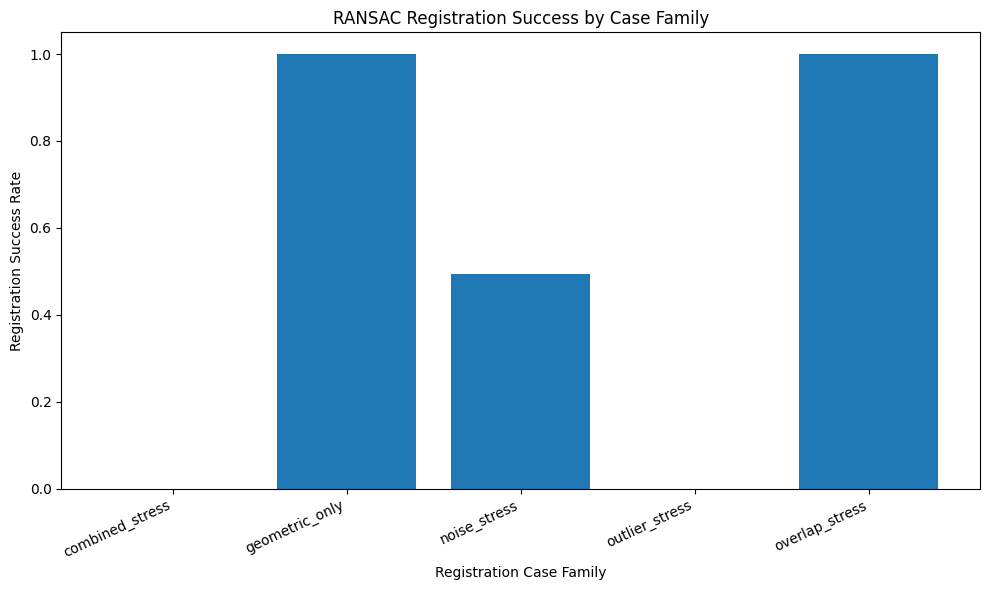

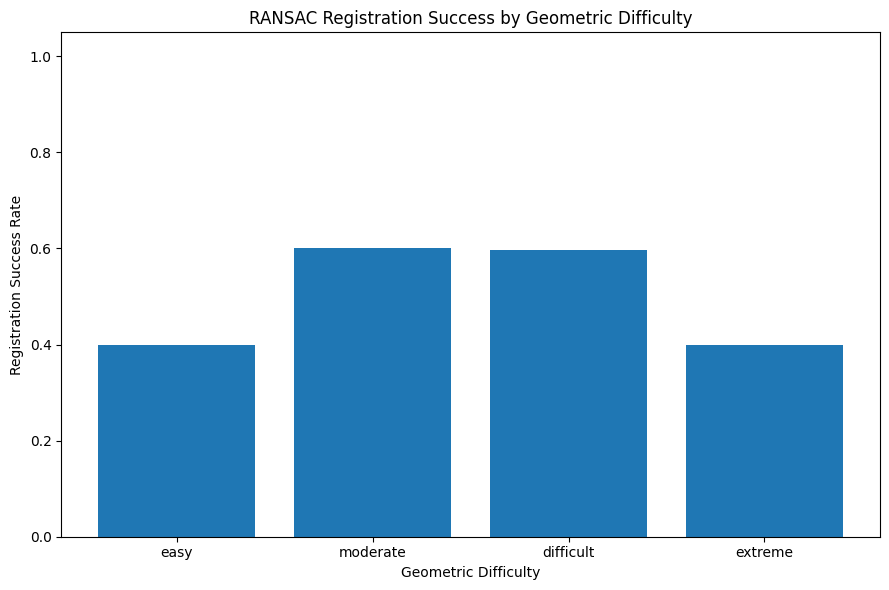

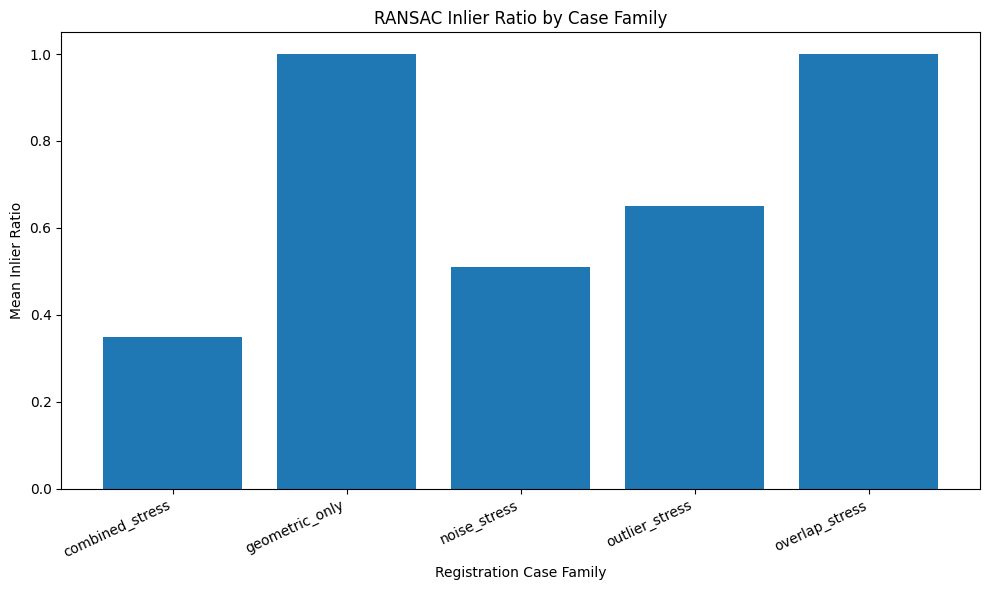

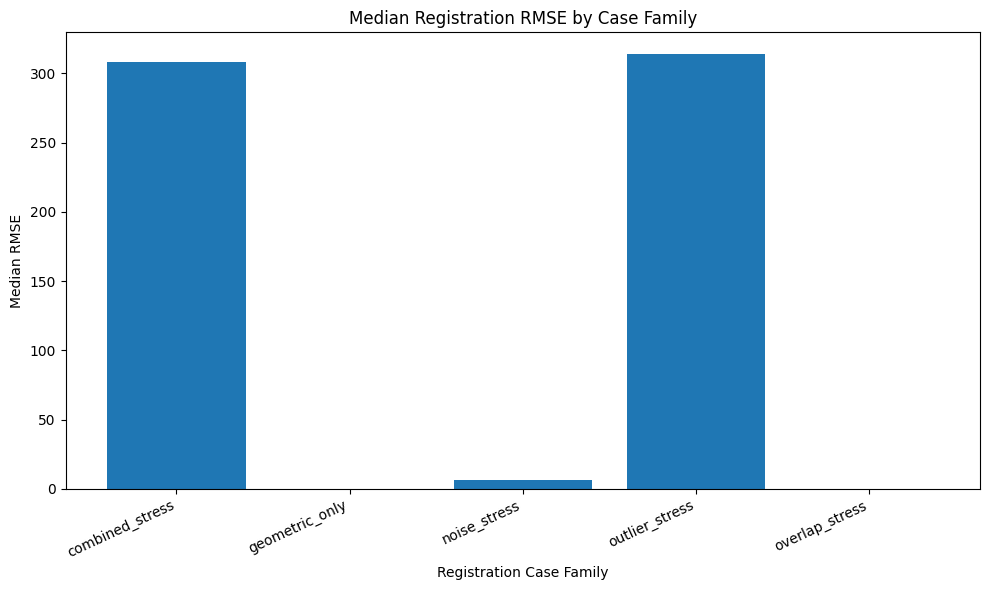


OVERALL REGISTRATION PERFORMANCE
Cases                 : 2000
Successful            : 998
Success rate          : 0.4990
Median RMSE           : 6.6173
Median inlier ratio   : 0.8989
Mean rotation error   : 0.1413 deg
Mean scale error      : 0.002253
Mean translation error: 2.8830

SUCCESS RATE BY CASE FAMILY
      case_type  cases  success_rate  median_rmse  mean_inlier_ratio  mean_rotation_error_deg  mean_translation_error
combined_stress    400         0.000   308.117127           0.349321             3.983991e-01                7.956801
 geometric_only    400         1.000     0.000026           1.000000             2.579574e-07                0.000004
   noise_stress    400         0.495     6.617262           0.510800             3.079126e-01                6.457674
 outlier_stress    400         0.000   313.965050           0.650878             1.918175e-05                0.000596
 overlap_stress    400         1.000     0.000027           1.000000             3.114116e-07     

In [8]:
# =============================================================================
# CELL 5 — REGISTRATION ROBUSTNESS ANALYSIS
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("REGISTRATION ROBUSTNESS ANALYSIS")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Locate required files
# -----------------------------------------------------------------------------

RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "registration_ransac_results.csv"
)

GROUND_TRUTH_METADATA_PATH = os.path.join(
    PAIRS_DIR,
    "ground_truth_registration_cases.csv"
)

if not os.path.exists(
    RESULTS_PATH
):
    raise FileNotFoundError(
        "RANSAC results were not found:\n"
        f"{RESULTS_PATH}\n\n"
        "Run Cell 4 first."
    )

if not os.path.exists(
    GROUND_TRUTH_METADATA_PATH
):
    raise FileNotFoundError(
        "Ground-truth metadata was not found:\n"
        f"{GROUND_TRUTH_METADATA_PATH}\n\n"
        "Run Cell 2 first."
    )

# -----------------------------------------------------------------------------
# 2. Load results
# -----------------------------------------------------------------------------

registration_results = pd.read_csv(
    RESULTS_PATH
)

ground_truth_metadata = pd.read_csv(
    GROUND_TRUTH_METADATA_PATH
)

print(
    f"RANSAC result rows       : "
    f"{len(registration_results)}"
)

print(
    f"Ground-truth rows        : "
    f"{len(ground_truth_metadata)}"
)

# -----------------------------------------------------------------------------
# 3. Validate case IDs
# -----------------------------------------------------------------------------

if (
    registration_results["case_id"]
    .nunique()
    !=
    len(registration_results)
):
    raise ValueError(
        "RANSAC results contain duplicate case IDs."
    )

if (
    ground_truth_metadata["case_id"]
    .nunique()
    !=
    len(ground_truth_metadata)
):
    raise ValueError(
        "Ground-truth metadata contain duplicate case IDs."
    )

# -----------------------------------------------------------------------------
# 4. Merge RANSAC results with ground-truth conditions
# -----------------------------------------------------------------------------

analysis_df = registration_results.merge(
    ground_truth_metadata,
    on="case_id",
    how="left",
    validate="one_to_one"
)

if len(analysis_df) != len(
    registration_results
):
    raise ValueError(
        "Some RANSAC cases could not be matched "
        "to ground-truth metadata."
    )

# -----------------------------------------------------------------------------
# 5. Define helper for robust summaries
# -----------------------------------------------------------------------------

def summarize_group(
    dataframe,
    group_column
):

    rows = []

    for group_value, group in dataframe.groupby(
        group_column,
        dropna=False
    ):

        rows.append(
            {
                group_column:
                    group_value,

                "cases":
                    len(group),

                "successful":
                    int(
                        group["success"]
                        .sum()
                    ),

                "success_rate":
                    float(
                        group["success"]
                        .mean()
                    ),

                "mean_rmse":
                    float(
                        group["rmse"]
                        .mean()
                    ),

                "median_rmse":
                    float(
                        group["rmse"]
                        .median()
                    ),

                "mean_inlier_ratio":
                    float(
                        group[
                            "inlier_ratio"
                        ].mean()
                    ),

                "median_inlier_ratio":
                    float(
                        group[
                            "inlier_ratio"
                        ].median()
                    ),

                "mean_rotation_error_deg":
                    float(
                        group[
                            "rotation_error_deg"
                        ].mean()
                    ),

                "median_rotation_error_deg":
                    float(
                        group[
                            "rotation_error_deg"
                        ].median()
                    ),

                "mean_scale_error":
                    float(
                        group[
                            "scale_error"
                        ].mean()
                    ),

                "mean_translation_error":
                    float(
                        group[
                            "translation_error"
                        ].mean()
                    ),

                "median_translation_error":
                    float(
                        group[
                            "translation_error"
                        ].median()
                    ),
            }
        )

    return pd.DataFrame(
        rows
    )


# -----------------------------------------------------------------------------
# 6. Overall summary
# -----------------------------------------------------------------------------

overall_summary = pd.DataFrame(
    [
        {
            "cases":
                len(analysis_df),

            "successful":
                int(
                    analysis_df[
                        "success"
                    ].sum()
                ),

            "success_rate":
                float(
                    analysis_df[
                        "success"
                    ].mean()
                ),

            "mean_rmse":
                float(
                    analysis_df[
                        "rmse"
                    ].mean()
                ),

            "median_rmse":
                float(
                    analysis_df[
                        "rmse"
                    ].median()
                ),

            "mean_inlier_ratio":
                float(
                    analysis_df[
                        "inlier_ratio"
                    ].mean()
                ),

            "median_inlier_ratio":
                float(
                    analysis_df[
                        "inlier_ratio"
                    ].median()
                ),

            "mean_rotation_error_deg":
                float(
                    analysis_df[
                        "rotation_error_deg"
                    ].mean()
                ),

            "mean_scale_error":
                float(
                    analysis_df[
                        "scale_error"
                    ].mean()
                ),

            "mean_translation_error":
                float(
                    analysis_df[
                        "translation_error"
                    ].mean()
                ),
        }
    ]
)

# -----------------------------------------------------------------------------
# 7. Summary by registration family
# -----------------------------------------------------------------------------

family_summary = summarize_group(
    analysis_df,
    "case_type"
)

family_summary_path = os.path.join(
    RESULTS_DIR,
    "registration_family_summary.csv"
)

family_summary.to_csv(
    family_summary_path,
    index=False
)

# -----------------------------------------------------------------------------
# 8. Summary by geometric difficulty
# -----------------------------------------------------------------------------

geometric_summary = summarize_group(
    analysis_df,
    "geometric_level"
)

geometric_summary_path = os.path.join(
    RESULTS_DIR,
    "registration_geometric_summary.csv"
)

geometric_summary.to_csv(
    geometric_summary_path,
    index=False
)

# -----------------------------------------------------------------------------
# 9. Summary by noise condition
# -----------------------------------------------------------------------------

noise_summary = summarize_group(
    analysis_df,
    "noise_level"
)

noise_summary_path = os.path.join(
    RESULTS_DIR,
    "registration_noise_summary.csv"
)

noise_summary.to_csv(
    noise_summary_path,
    index=False
)

# -----------------------------------------------------------------------------
# 10. Summary by outlier condition
# -----------------------------------------------------------------------------

outlier_summary = summarize_group(
    analysis_df,
    "outlier_level"
)

outlier_summary_path = os.path.join(
    RESULTS_DIR,
    "registration_outlier_summary.csv"
)

outlier_summary.to_csv(
    outlier_summary_path,
    index=False
)

# -----------------------------------------------------------------------------
# 11. Summary by overlap condition
# -----------------------------------------------------------------------------

overlap_summary = summarize_group(
    analysis_df,
    "overlap_level"
)

overlap_summary_path = os.path.join(
    RESULTS_DIR,
    "registration_overlap_summary.csv"
)

overlap_summary.to_csv(
    overlap_summary_path,
    index=False
)

# -----------------------------------------------------------------------------
# 12. Identify hardest cases
# -----------------------------------------------------------------------------

hardest_cases = (
    analysis_df
    .sort_values(
        by=[
            "success",
            "rmse",
            "translation_error",
        ],
        ascending=[
            True,
            False,
            False,
        ]
    )
    .head(25)
)

hardest_cases_path = os.path.join(
    RESULTS_DIR,
    "registration_hardest_cases.csv"
)

hardest_cases.to_csv(
    hardest_cases_path,
    index=False
)

# -----------------------------------------------------------------------------
# 13. Create combined condition table
# -----------------------------------------------------------------------------

condition_summary = (
    analysis_df
    .groupby(
        [
            "case_type",
            "geometric_level",
            "noise_level",
            "outlier_level",
            "overlap_level",
        ],
        dropna=False
    )
    .agg(
        cases=(
            "case_id",
            "count"
        ),

        success_rate=(
            "success",
            "mean"
        ),

        median_rmse=(
            "rmse",
            "median"
        ),

        median_inlier_ratio=(
            "inlier_ratio",
            "median"
        ),

        median_rotation_error_deg=(
            "rotation_error_deg",
            "median"
        ),

        median_scale_error=(
            "scale_error",
            "median"
        ),

        median_translation_error=(
            "translation_error",
            "median"
        ),
    )
    .reset_index()
)

condition_summary_path = os.path.join(
    RESULTS_DIR,
    "registration_condition_summary.csv"
)

condition_summary.to_csv(
    condition_summary_path,
    index=False
)

# -----------------------------------------------------------------------------
# 14. Plot 1 — Success rate by case family
# -----------------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    family_summary["case_type"],
    family_summary["success_rate"]
)

plt.ylabel(
    "Registration Success Rate"
)

plt.xlabel(
    "Registration Case Family"
)

plt.title(
    "RANSAC Registration Success by Case Family"
)

plt.ylim(
    0.0,
    1.05
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

family_success_plot = os.path.join(
    FIGURES_DIR,
    "registration_success_by_family.png"
)

plt.savefig(
    family_success_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 15. Plot 2 — Success rate by geometric difficulty
# -----------------------------------------------------------------------------

geometric_order = [
    "easy",
    "moderate",
    "difficult",
    "extreme",
]

geometric_plot_df = (
    geometric_summary
    .set_index(
        "geometric_level"
    )
    .reindex(
        geometric_order
    )
    .reset_index()
)

plt.figure(
    figsize=(9, 6)
)

plt.bar(
    geometric_plot_df[
        "geometric_level"
    ],
    geometric_plot_df[
        "success_rate"
    ]
)

plt.ylabel(
    "Registration Success Rate"
)

plt.xlabel(
    "Geometric Difficulty"
)

plt.title(
    "RANSAC Registration Success by Geometric Difficulty"
)

plt.ylim(
    0.0,
    1.05
)

plt.tight_layout()

geometric_success_plot = os.path.join(
    FIGURES_DIR,
    "registration_success_by_geometric_difficulty.png"
)

plt.savefig(
    geometric_success_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 16. Plot 3 — Inlier ratio by case family
# -----------------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    family_summary["case_type"],
    family_summary[
        "mean_inlier_ratio"
    ]
)

plt.ylabel(
    "Mean Inlier Ratio"
)

plt.xlabel(
    "Registration Case Family"
)

plt.title(
    "RANSAC Inlier Ratio by Case Family"
)

plt.ylim(
    0.0,
    1.05
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

inlier_plot = os.path.join(
    FIGURES_DIR,
    "registration_inlier_ratio_by_family.png"
)

plt.savefig(
    inlier_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 17. Plot 4 — Median RMSE by case family
# -----------------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    family_summary["case_type"],
    family_summary[
        "median_rmse"
    ]
)

plt.ylabel(
    "Median RMSE"
)

plt.xlabel(
    "Registration Case Family"
)

plt.title(
    "Median Registration RMSE by Case Family"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

rmse_plot = os.path.join(
    FIGURES_DIR,
    "registration_rmse_by_family.png"
)

plt.savefig(
    rmse_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 18. Save overall summary
# -----------------------------------------------------------------------------

overall_summary_path = os.path.join(
    RESULTS_DIR,
    "registration_overall_summary.csv"
)

overall_summary.to_csv(
    overall_summary_path,
    index=False
)

# -----------------------------------------------------------------------------
# 19. Print results
# -----------------------------------------------------------------------------

print()
print("=" * 80)
print("OVERALL REGISTRATION PERFORMANCE")
print("=" * 80)

print(
    f"Cases                 : "
    f"{len(analysis_df)}"
)

print(
    f"Successful            : "
    f"{int(analysis_df['success'].sum())}"
)

print(
    f"Success rate          : "
    f"{analysis_df['success'].mean():.4f}"
)

print(
    f"Median RMSE           : "
    f"{analysis_df['rmse'].median():.4f}"
)

print(
    f"Median inlier ratio   : "
    f"{analysis_df['inlier_ratio'].median():.4f}"
)

print(
    f"Mean rotation error   : "
    f"{analysis_df['rotation_error_deg'].mean():.4f} deg"
)

print(
    f"Mean scale error      : "
    f"{analysis_df['scale_error'].mean():.6f}"
)

print(
    f"Mean translation error: "
    f"{analysis_df['translation_error'].mean():.4f}"
)

print()

print("=" * 80)
print("SUCCESS RATE BY CASE FAMILY")
print("=" * 80)

print(
    family_summary[
        [
            "case_type",
            "cases",
            "success_rate",
            "median_rmse",
            "mean_inlier_ratio",
            "mean_rotation_error_deg",
            "mean_translation_error",
        ]
    ].to_string(
        index=False
    )
)

print()

print("=" * 80)
print("SUCCESS RATE BY GEOMETRIC DIFFICULTY")
print("=" * 80)

print(
    geometric_plot_df[
        [
            "geometric_level",
            "cases",
            "success_rate",
            "median_rmse",
            "mean_inlier_ratio",
        ]
    ].to_string(
        index=False
    )
)

print()

print("=" * 80)
print("SUCCESS RATE BY NOISE CONDITION")
print("=" * 80)

print(
    noise_summary[
        [
            "noise_level",
            "cases",
            "success_rate",
            "median_rmse",
            "mean_inlier_ratio",
        ]
    ].to_string(
        index=False
    )
)

print()

print("=" * 80)
print("SUCCESS RATE BY OUTLIER CONDITION")
print("=" * 80)

print(
    outlier_summary[
        [
            "outlier_level",
            "cases",
            "success_rate",
            "median_rmse",
            "mean_inlier_ratio",
        ]
    ].to_string(
        index=False
    )
)

print()

print("=" * 80)
print("SUCCESS RATE BY OVERLAP CONDITION")
print("=" * 80)

print(
    overlap_summary[
        [
            "overlap_level",
            "cases",
            "success_rate",
            "median_rmse",
            "mean_inlier_ratio",
        ]
    ].to_string(
        index=False
    )
)

print()

print("=" * 80)
print("OUTPUT FILES")
print("=" * 80)

print(
    f"  {overall_summary_path}"
)

print(
    f"  {family_summary_path}"
)

print(
    f"  {geometric_summary_path}"
)

print(
    f"  {noise_summary_path}"
)

print(
    f"  {outlier_summary_path}"
)

print(
    f"  {overlap_summary_path}"
)

print(
    f"  {condition_summary_path}"
)

print(
    f"  {hardest_cases_path}"
)

print(
    f"  {family_success_plot}"
)

print(
    f"  {geometric_success_plot}"
)

print(
    f"  {inlier_plot}"
)

print(
    f"  {rmse_plot}"
)

print()
print(
    "[OK] RANSAC results joined with ground-truth conditions."
)

print(
    "[OK] Family-level robustness analysis completed."
)

print(
    "[OK] Geometric difficulty analysis completed."
)

print(
    "[OK] Noise/outlier/overlap analysis completed."
)

print(
    "[OK] Hardest cases identified."
)

print(
    "[OK] Summary tables and figures saved."
)

print("=" * 80)
print("CELL 5 COMPLETE")
print("=" * 80)

In [9]:
# =============================================================================
# CELL 6 — CORRECTED ROBUST REGISTRATION EVALUATION
# =============================================================================

import os
import cv2
import numpy as np
import pandas as pd

print("=" * 80)
print("CORRECTED ROBUST REGISTRATION EVALUATION")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Configuration
# -----------------------------------------------------------------------------

RANSAC_THRESHOLDS_PX = [
    3.0,
    5.0,
    8.0,
    12.0,
]

RANSAC_MAX_TRIALS_LOCAL = 5000
RANSAC_CONFIDENCE_LOCAL = 0.995

SUCCESS_MAX_RMSE_LOCAL = 10.0
SUCCESS_MAX_ROTATION_ERROR_DEG_LOCAL = 3.0
SUCCESS_MAX_SCALE_ERROR_LOCAL = 0.05
SUCCESS_MAX_TRANSLATION_ERROR_LOCAL = 15.0
SUCCESS_MIN_INLIER_RATIO_LOCAL = 0.50

# -----------------------------------------------------------------------------
# 2. Required input paths
# -----------------------------------------------------------------------------

if not os.path.exists(
    OBSERVED_POINTS_PATH
):
    raise FileNotFoundError(
        "Observed registration cases were not found:\n"
        f"{OBSERVED_POINTS_PATH}\n\n"
        "Run Cell 3 first."
    )

if not os.path.exists(
    GROUND_TRUTH_POINTS_PATH
):
    raise FileNotFoundError(
        "Ground-truth registration cases were not found:\n"
        f"{GROUND_TRUTH_POINTS_PATH}\n\n"
        "Run Cell 2 first."
    )

if not os.path.exists(
    GROUND_TRUTH_METADATA_PATH
):
    raise FileNotFoundError(
        "Ground-truth metadata were not found:\n"
        f"{GROUND_TRUTH_METADATA_PATH}\n\n"
        "Run Cell 2 first."
    )

# -----------------------------------------------------------------------------
# 3. Load observed correspondences
# -----------------------------------------------------------------------------

with np.load(
    OBSERVED_POINTS_PATH,
    allow_pickle=True
) as observed_data:

    observed_sources = observed_data[
        "observed_source"
    ]

    observed_targets = observed_data[
        "observed_target"
    ]

    true_match_labels = observed_data[
        "is_true_match"
    ]

    observed_case_ids = observed_data[
        "case_id"
    ]

# -----------------------------------------------------------------------------
# 4. Load ground truth
# -----------------------------------------------------------------------------

with np.load(
    GROUND_TRUTH_POINTS_PATH,
    allow_pickle=True
) as ground_truth_data:

    gt_transform_matrices = (
        ground_truth_data[
            "transform_matrices"
        ]
    )

    gt_case_ids = (
        ground_truth_data[
            "case_id"
        ]
    )

ground_truth_metadata = pd.read_csv(
    GROUND_TRUTH_METADATA_PATH
)

# -----------------------------------------------------------------------------
# 5. Validate inputs
# -----------------------------------------------------------------------------

if len(observed_sources) != TOTAL_CASES:
    raise ValueError(
        "Observed source case count does not match TOTAL_CASES."
    )

if len(observed_targets) != TOTAL_CASES:
    raise ValueError(
        "Observed target case count does not match TOTAL_CASES."
    )

if len(true_match_labels) != TOTAL_CASES:
    raise ValueError(
        "Observed label case count does not match TOTAL_CASES."
    )

if len(gt_transform_matrices) != TOTAL_CASES:
    raise ValueError(
        "Ground-truth transformation count does not match TOTAL_CASES."
    )

if not np.array_equal(
    observed_case_ids,
    gt_case_ids
):
    raise ValueError(
        "Observed and ground-truth case IDs are not aligned."
    )

print(
    f"Registration cases        : "
    f"{TOTAL_CASES}"
)

print(
    f"RANSAC thresholds         : "
    f"{RANSAC_THRESHOLDS_PX}"
)

# -----------------------------------------------------------------------------
# 6. Utility functions
# -----------------------------------------------------------------------------

def extract_similarity_parameters(
    H
):
    """
    Extract rotation, scale and translation
    from a 3x3 similarity transform.
    """

    rotation_deg = np.degrees(
        np.arctan2(
            H[1, 0],
            H[0, 0]
        )
    )

    scale = np.sqrt(
        H[0, 0] ** 2
        +
        H[1, 0] ** 2
    )

    translation = H[
        :2,
        2
    ]

    return (
        float(rotation_deg),
        float(scale),
        np.asarray(
            translation,
            dtype=np.float64
        )
    )


def angular_difference_deg(
    angle_a,
    angle_b
):
    """
    Smallest absolute angular difference.
    """

    difference = abs(
        float(angle_a)
        -
        float(angle_b)
    )

    return min(
        difference,
        360.0 - difference
    )


# -----------------------------------------------------------------------------
# 7. Run RANSAC for every threshold
# -----------------------------------------------------------------------------

ALL_THRESHOLD_RESULTS = []

for threshold in RANSAC_THRESHOLDS_PX:

    print()
    print(
        "-" * 80
    )

    print(
        f"Running RANSAC threshold = "
        f"{threshold:.1f} px"
    )

    print(
        "-" * 80
    )

    for case_position in range(
        TOTAL_CASES
    ):

        case_id = int(
            observed_case_ids[
                case_position
            ]
        )

        src = np.asarray(
            observed_sources[
                case_position
            ],
            dtype=np.float64
        )

        dst = np.asarray(
            observed_targets[
                case_position
            ],
            dtype=np.float64
        )

        true_labels = np.asarray(
            true_match_labels[
                case_position
            ],
            dtype=bool
        )

        gt_H = np.asarray(
            gt_transform_matrices[
                case_position
            ],
            dtype=np.float64
        )

        # ---------------------------------------------------------------------
        # RANSAC similarity estimation
        # ---------------------------------------------------------------------

        estimated_affine, ransac_mask = (
            cv2.estimateAffinePartial2D(
                src.astype(np.float32),
                dst.astype(np.float32),
                method=cv2.RANSAC,
                ransacReprojThreshold=float(
                    threshold
                ),
                maxIters=RANSAC_MAX_TRIALS_LOCAL,
                confidence=RANSAC_CONFIDENCE_LOCAL,
                refineIters=10
            )
        )

        # ---------------------------------------------------------------------
        # Failed estimation
        # ---------------------------------------------------------------------

        if (
            estimated_affine is None
            or
            ransac_mask is None
        ):

            ALL_THRESHOLD_RESULTS.append(
                {
                    "case_id":
                        case_id,

                    "ransac_threshold_px":
                        float(threshold),

                    "estimation_failed":
                        True,

                    "all_point_rmse":
                        np.nan,

                    "inlier_rmse":
                        np.nan,

                    "inlier_count":
                        0,

                    "inlier_ratio":
                        0.0,

                    "true_inlier_count":
                        0,

                    "false_inlier_count":
                        0,

                    "true_inlier_precision":
                        0.0,

                    "true_inlier_recall":
                        0.0,

                    "rotation_error_deg":
                        np.nan,

                    "scale_error":
                        np.nan,

                    "translation_error":
                        np.nan,

                    "success":
                        False,
                }
            )

            continue

        # ---------------------------------------------------------------------
        # Convert to homogeneous matrix
        # ---------------------------------------------------------------------

        H = np.eye(
            3,
            dtype=np.float64
        )

        H[
            :2,
            :
        ] = estimated_affine

        # ---------------------------------------------------------------------
        # Predicted target coordinates
        # ---------------------------------------------------------------------

        src_h = np.column_stack(
            [
                src,
                np.ones(
                    len(src),
                    dtype=np.float64
                ),
            ]
        )

        predicted = (
            H @ src_h.T
        ).T[
            :,
            :2
        ]

        residuals = np.linalg.norm(
            predicted - dst,
            axis=1
        )

        # ---------------------------------------------------------------------
        # RANSAC inlier mask
        # ---------------------------------------------------------------------

        inlier_mask = (
            ransac_mask
            .ravel()
            .astype(bool)
        )

        inlier_count = int(
            inlier_mask.sum()
        )

        inlier_ratio = (
            inlier_count
            /
            len(src)
        )

        # ---------------------------------------------------------------------
        # ALL-point RMSE
        #
        # Diagnostic only.
        # This includes deliberately fabricated false matches.
        # ---------------------------------------------------------------------

        all_point_rmse = float(
            np.sqrt(
                np.mean(
                    residuals ** 2
                )
            )
        )

        # ---------------------------------------------------------------------
        # INLIER-ONLY RMSE
        #
        # This is the principal geometric registration RMSE.
        # ---------------------------------------------------------------------

        if inlier_count > 0:

            inlier_rmse = float(
                np.sqrt(
                    np.mean(
                        residuals[
                            inlier_mask
                        ] ** 2
                    )
                )
            )

        else:

            inlier_rmse = np.nan

        # ---------------------------------------------------------------------
        # True/false inlier diagnostics
        #
        # These labels are NOT used by RANSAC.
        # They are only used to evaluate whether RANSAC selected
        # the correct correspondences.
        # ---------------------------------------------------------------------

        true_inlier_count = int(
            np.sum(
                inlier_mask
                &
                true_labels
            )
        )

        false_inlier_count = int(
            np.sum(
                inlier_mask
                &
                (~true_labels)
            )
        )

        total_true_matches = int(
            true_labels.sum()
        )

        if inlier_count > 0:

            true_inlier_precision = (
                true_inlier_count
                /
                inlier_count
            )

        else:

            true_inlier_precision = 0.0

        if total_true_matches > 0:

            true_inlier_recall = (
                true_inlier_count
                /
                total_true_matches
            )

        else:

            true_inlier_recall = 0.0

        # ---------------------------------------------------------------------
        # Ground-truth transformation parameters
        # ---------------------------------------------------------------------

        (
            gt_rotation,
            gt_scale,
            gt_translation
        ) = extract_similarity_parameters(
            gt_H
        )

        # ---------------------------------------------------------------------
        # Estimated transformation parameters
        # ---------------------------------------------------------------------

        (
            estimated_rotation,
            estimated_scale,
            estimated_translation
        ) = extract_similarity_parameters(
            H
        )

        # ---------------------------------------------------------------------
        # Parameter errors
        # ---------------------------------------------------------------------

        rotation_error = (
            angular_difference_deg(
                estimated_rotation,
                gt_rotation
            )
        )

        scale_error = abs(
            estimated_scale
            -
            gt_scale
        )

        translation_error = float(
            np.linalg.norm(
                estimated_translation
                -
                gt_translation
            )
        )

        # ---------------------------------------------------------------------
        # Registration success
        #
        # IMPORTANT:
        # Success now uses INLIER-ONLY RMSE.
        # ---------------------------------------------------------------------

        success = (
            np.isfinite(
                inlier_rmse
            )
            and
            inlier_rmse
            <=
            SUCCESS_MAX_RMSE_LOCAL
            and
            rotation_error
            <=
            SUCCESS_MAX_ROTATION_ERROR_DEG_LOCAL
            and
            scale_error
            <=
            SUCCESS_MAX_SCALE_ERROR_LOCAL
            and
            translation_error
            <=
            SUCCESS_MAX_TRANSLATION_ERROR_LOCAL
            and
            inlier_ratio
            >=
            SUCCESS_MIN_INLIER_RATIO_LOCAL
        )

        ALL_THRESHOLD_RESULTS.append(
            {
                "case_id":
                    case_id,

                "ransac_threshold_px":
                    float(threshold),

                "estimation_failed":
                    False,

                "all_point_rmse":
                    all_point_rmse,

                "inlier_rmse":
                    inlier_rmse,

                "inlier_count":
                    inlier_count,

                "inlier_ratio":
                    inlier_ratio,

                "true_inlier_count":
                    true_inlier_count,

                "false_inlier_count":
                    false_inlier_count,

                "true_inlier_precision":
                    true_inlier_precision,

                "true_inlier_recall":
                    true_inlier_recall,

                "rotation_error_deg":
                    rotation_error,

                "scale_error":
                    scale_error,

                "translation_error":
                    translation_error,

                "success":
                    bool(success),
            }
        )

# -----------------------------------------------------------------------------
# 8. Convert to DataFrame
# -----------------------------------------------------------------------------

threshold_results = pd.DataFrame(
    ALL_THRESHOLD_RESULTS
)

# -----------------------------------------------------------------------------
# 9. Add ground-truth metadata
# -----------------------------------------------------------------------------

threshold_results = threshold_results.merge(
    ground_truth_metadata,
    on="case_id",
    how="left",
    validate="many_to_one"
)

# -----------------------------------------------------------------------------
# 10. Validate result count
# -----------------------------------------------------------------------------

expected_result_rows = (
    TOTAL_CASES
    *
    len(RANSAC_THRESHOLDS_PX)
)

if len(threshold_results) != (
    expected_result_rows
):
    raise RuntimeError(
        "Unexpected number of threshold evaluation rows. "
        f"Expected {expected_result_rows}, "
        f"got {len(threshold_results)}."
    )

# -----------------------------------------------------------------------------
# 11. Save complete threshold results
# -----------------------------------------------------------------------------

THRESHOLD_RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "registration_ransac_threshold_sensitivity.csv"
)

threshold_results.to_csv(
    THRESHOLD_RESULTS_PATH,
    index=False
)

# -----------------------------------------------------------------------------
# 12. Threshold-level summary
# -----------------------------------------------------------------------------

threshold_summary = (
    threshold_results
    .groupby(
        "ransac_threshold_px"
    )
    .agg(
        cases=(
            "case_id",
            "count"
        ),

        successful=(
            "success",
            "sum"
        ),

        success_rate=(
            "success",
            "mean"
        ),

        mean_inlier_rmse=(
            "inlier_rmse",
            "mean"
        ),

        median_inlier_rmse=(
            "inlier_rmse",
            "median"
        ),

        mean_all_point_rmse=(
            "all_point_rmse",
            "mean"
        ),

        median_all_point_rmse=(
            "all_point_rmse",
            "median"
        ),

        mean_inlier_ratio=(
            "inlier_ratio",
            "mean"
        ),

        median_inlier_ratio=(
            "inlier_ratio",
            "median"
        ),

        mean_true_inlier_precision=(
            "true_inlier_precision",
            "mean"
        ),

        mean_true_inlier_recall=(
            "true_inlier_recall",
            "mean"
        ),

        mean_rotation_error_deg=(
            "rotation_error_deg",
            "mean"
        ),

        mean_scale_error=(
            "scale_error",
            "mean"
        ),

        mean_translation_error=(
            "translation_error",
            "mean"
        ),
    )
    .reset_index()
)

THRESHOLD_SUMMARY_PATH = os.path.join(
    RESULTS_DIR,
    "registration_ransac_threshold_summary.csv"
)

threshold_summary.to_csv(
    THRESHOLD_SUMMARY_PATH,
    index=False
)

# -----------------------------------------------------------------------------
# 13. Select best threshold
#
# Primary criterion:
#     highest registration success rate
#
# Tie-breakers:
#     lowest median inlier RMSE
#     highest mean inlier ratio
# -----------------------------------------------------------------------------

threshold_summary_sorted = (
    threshold_summary
    .sort_values(
        by=[
            "success_rate",
            "median_inlier_rmse",
            "mean_inlier_ratio",
        ],
        ascending=[
            False,
            True,
            False,
        ]
    )
)

best_threshold_row = (
    threshold_summary_sorted
    .iloc[0]
)

BEST_RANSAC_THRESHOLD = float(
    best_threshold_row[
        "ransac_threshold_px"
    ]
)

# -----------------------------------------------------------------------------
# 14. Best-threshold results
# -----------------------------------------------------------------------------

best_threshold_results = (
    threshold_results[
        threshold_results[
            "ransac_threshold_px"
        ]
        ==
        BEST_RANSAC_THRESHOLD
    ]
    .copy()
)

BEST_RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "registration_final_results.csv"
)

best_threshold_results.to_csv(
    BEST_RESULTS_PATH,
    index=False
)

# -----------------------------------------------------------------------------
# 15. Family summary at the selected threshold
# -----------------------------------------------------------------------------

best_family_summary = (
    best_threshold_results
    .groupby(
        "case_type"
    )
    .agg(
        cases=(
            "case_id",
            "count"
        ),

        successful=(
            "success",
            "sum"
        ),

        success_rate=(
            "success",
            "mean"
        ),

        median_inlier_rmse=(
            "inlier_rmse",
            "median"
        ),

        mean_inlier_ratio=(
            "inlier_ratio",
            "mean"
        ),

        mean_true_inlier_precision=(
            "true_inlier_precision",
            "mean"
        ),

        mean_true_inlier_recall=(
            "true_inlier_recall",
            "mean"
        ),

        mean_rotation_error_deg=(
            "rotation_error_deg",
            "mean"
        ),

        mean_scale_error=(
            "scale_error",
            "mean"
        ),

        mean_translation_error=(
            "translation_error",
            "mean"
        ),
    )
    .reset_index()
)

BEST_FAMILY_SUMMARY_PATH = os.path.join(
    RESULTS_DIR,
    "registration_final_family_summary.csv"
)

best_family_summary.to_csv(
    BEST_FAMILY_SUMMARY_PATH,
    index=False
)

# -----------------------------------------------------------------------------
# 16. Overall final summary
# -----------------------------------------------------------------------------

final_summary = pd.DataFrame(
    [
        {
            "selected_ransac_threshold_px":
                BEST_RANSAC_THRESHOLD,

            "cases":
                len(
                    best_threshold_results
                ),

            "successful":
                int(
                    best_threshold_results[
                        "success"
                    ].sum()
                ),

            "success_rate":
                float(
                    best_threshold_results[
                        "success"
                    ].mean()
                ),

            "median_inlier_rmse":
                float(
                    best_threshold_results[
                        "inlier_rmse"
                    ].median()
                ),

            "mean_inlier_rmse":
                float(
                    best_threshold_results[
                        "inlier_rmse"
                    ].mean()
                ),

            "median_inlier_ratio":
                float(
                    best_threshold_results[
                        "inlier_ratio"
                    ].median()
                ),

            "mean_inlier_ratio":
                float(
                    best_threshold_results[
                        "inlier_ratio"
                    ].mean()
                ),

            "mean_true_inlier_precision":
                float(
                    best_threshold_results[
                        "true_inlier_precision"
                    ].mean()
                ),

            "mean_true_inlier_recall":
                float(
                    best_threshold_results[
                        "true_inlier_recall"
                    ].mean()
                ),

            "mean_rotation_error_deg":
                float(
                    best_threshold_results[
                        "rotation_error_deg"
                    ].mean()
                ),

            "mean_scale_error":
                float(
                    best_threshold_results[
                        "scale_error"
                    ].mean()
                ),

            "mean_translation_error":
                float(
                    best_threshold_results[
                        "translation_error"
                    ].mean()
                ),
        }
    ]
)

FINAL_SUMMARY_PATH = os.path.join(
    RESULTS_DIR,
    "registration_final_summary.csv"
)

final_summary.to_csv(
    FINAL_SUMMARY_PATH,
    index=False
)

# -----------------------------------------------------------------------------
# 17. Print threshold comparison
# -----------------------------------------------------------------------------

print()
print("=" * 80)
print("RANSAC THRESHOLD SENSITIVITY")
print("=" * 80)

print(
    threshold_summary[
        [
            "ransac_threshold_px",
            "success_rate",
            "median_inlier_rmse",
            "mean_inlier_ratio",
            "mean_true_inlier_precision",
            "mean_true_inlier_recall",
            "mean_rotation_error_deg",
            "mean_translation_error",
        ]
    ].to_string(
        index=False
    )
)

# -----------------------------------------------------------------------------
# 18. Print selected final result
# -----------------------------------------------------------------------------

print()
print("=" * 80)
print("SELECTED FINAL RANSAC CONFIGURATION")
print("=" * 80)

print(
    f"Selected threshold     : "
    f"{BEST_RANSAC_THRESHOLD:.1f} px"
)

print(
    f"Registration cases     : "
    f"{len(best_threshold_results)}"
)

print(
    f"Successful cases       : "
    f"{int(best_threshold_results['success'].sum())}"
)

print(
    f"Success rate           : "
    f"{best_threshold_results['success'].mean():.4f}"
)

print(
    f"Median inlier RMSE     : "
    f"{best_threshold_results['inlier_rmse'].median():.4f}"
)

print(
    f"Mean inlier RMSE       : "
    f"{best_threshold_results['inlier_rmse'].mean():.4f}"
)

print(
    f"Median inlier ratio    : "
    f"{best_threshold_results['inlier_ratio'].median():.4f}"
)

print(
    f"Mean inlier ratio      : "
    f"{best_threshold_results['inlier_ratio'].mean():.4f}"
)

print(
    f"True-inlier precision  : "
    f"{best_threshold_results['true_inlier_precision'].mean():.4f}"
)

print(
    f"True-inlier recall     : "
    f"{best_threshold_results['true_inlier_recall'].mean():.4f}"
)

print(
    f"Mean rotation error    : "
    f"{best_threshold_results['rotation_error_deg'].mean():.4f} deg"
)

print(
    f"Mean scale error       : "
    f"{best_threshold_results['scale_error'].mean():.6f}"
)

print(
    f"Mean translation error : "
    f"{best_threshold_results['translation_error'].mean():.4f}"
)

# -----------------------------------------------------------------------------
# 19. Print family-level final results
# -----------------------------------------------------------------------------

print()
print("=" * 80)
print("FINAL PERFORMANCE BY REGISTRATION FAMILY")
print("=" * 80)

print(
    best_family_summary[
        [
            "case_type",
            "cases",
            "success_rate",
            "median_inlier_rmse",
            "mean_inlier_ratio",
            "mean_true_inlier_precision",
            "mean_true_inlier_recall",
            "mean_rotation_error_deg",
            "mean_translation_error",
        ]
    ].to_string(
        index=False
    )
)

# -----------------------------------------------------------------------------
# 20. Output paths
# -----------------------------------------------------------------------------

print()
print("=" * 80)
print("OUTPUT FILES")
print("=" * 80)

print(
    f"  {THRESHOLD_RESULTS_PATH}"
)

print(
    f"  {THRESHOLD_SUMMARY_PATH}"
)

print(
    f"  {BEST_RESULTS_PATH}"
)

print(
    f"  {BEST_FAMILY_SUMMARY_PATH}"
)

print(
    f"  {FINAL_SUMMARY_PATH}"
)

print()

print(
    "[OK] RANSAC threshold sensitivity evaluated."
)

print(
    "[OK] Inlier-only RMSE calculated."
)

print(
    "[OK] All-point RMSE retained as a diagnostic."
)

print(
    "[OK] True/false inlier diagnostics calculated."
)

print(
    "[OK] Ground-truth transformation errors calculated."
)

print(
    "[OK] Registration success criteria applied."
)

print(
    "[OK] Best RANSAC threshold selected."
)

print(
    "[OK] Final registration results saved."
)

print("=" * 80)
print("CELL 6 COMPLETE")
print("=" * 80)

CORRECTED ROBUST REGISTRATION EVALUATION
Registration cases        : 2000
RANSAC thresholds         : [3.0, 5.0, 8.0, 12.0]

--------------------------------------------------------------------------------
Running RANSAC threshold = 3.0 px
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Running RANSAC threshold = 5.0 px
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Running RANSAC threshold = 8.0 px
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Running RANSAC threshold = 12.0 px
--------------------------------------------------------------------------------

RANSAC THRESHOLD SENSITIVITY
 ransac_threshold_px  success_rate  median_inlier_rmse  m

FINAL REGISTRATION ROBUSTNESS VISUALIZATION


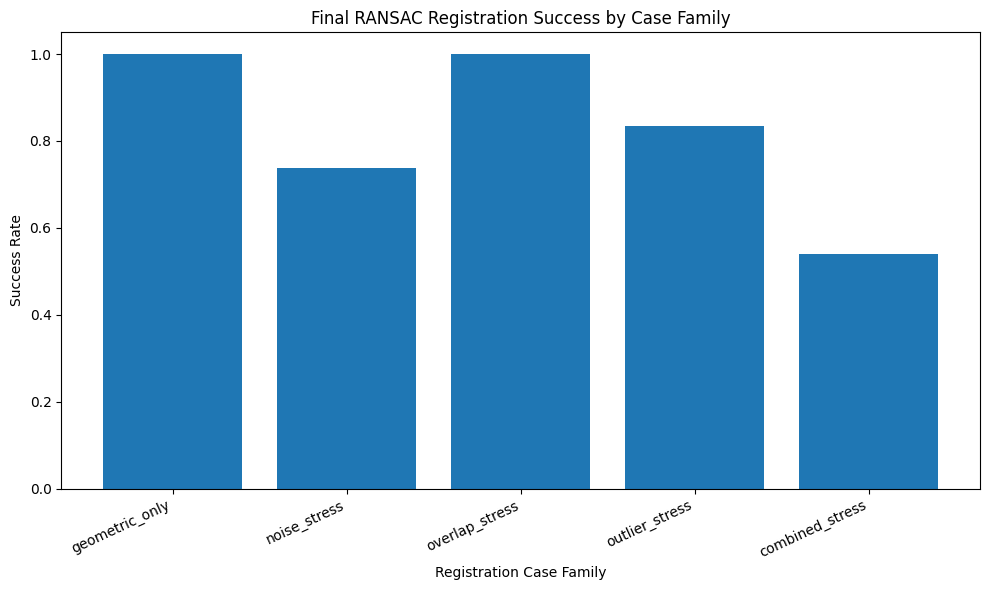

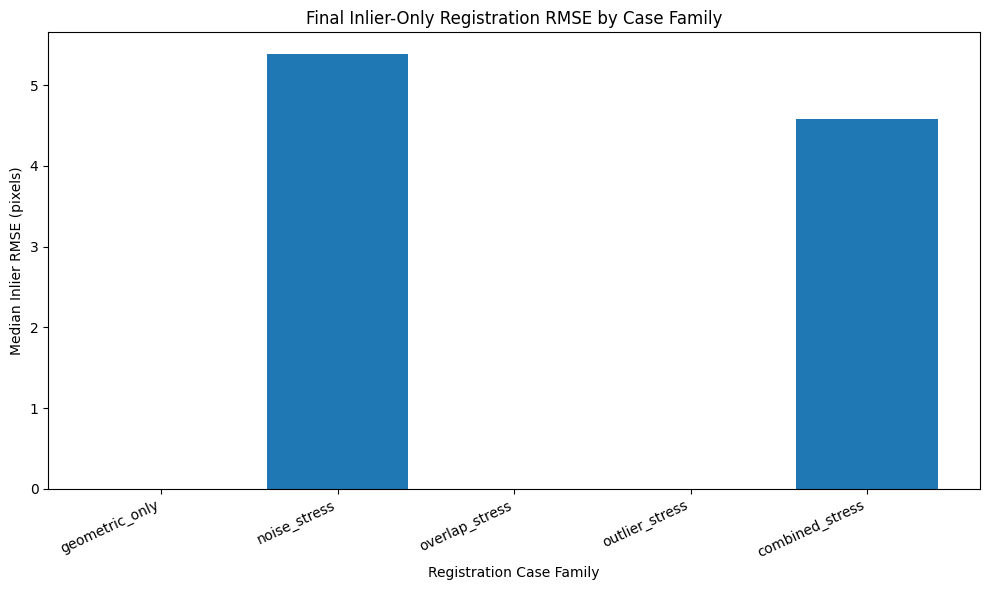

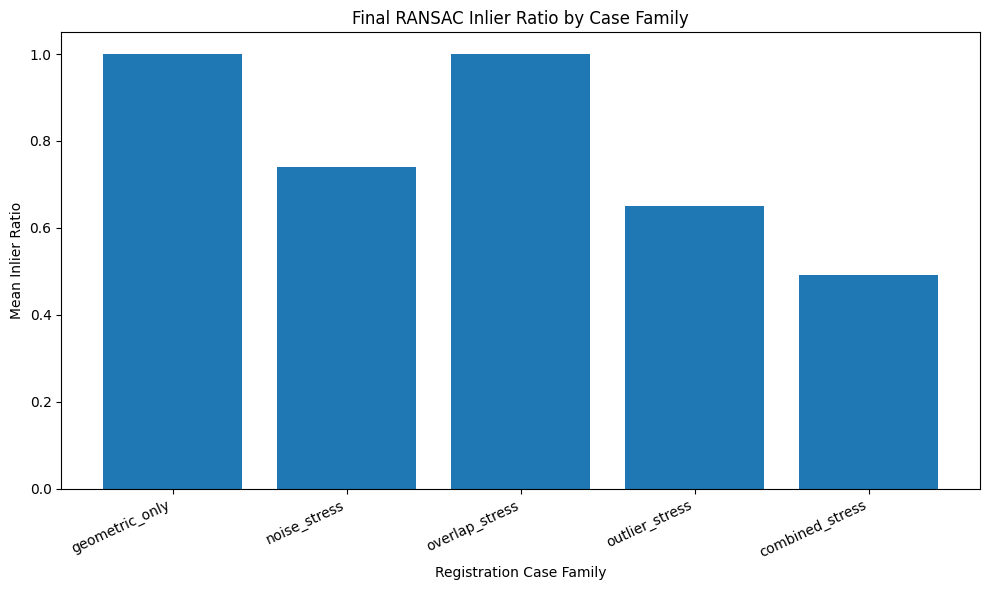

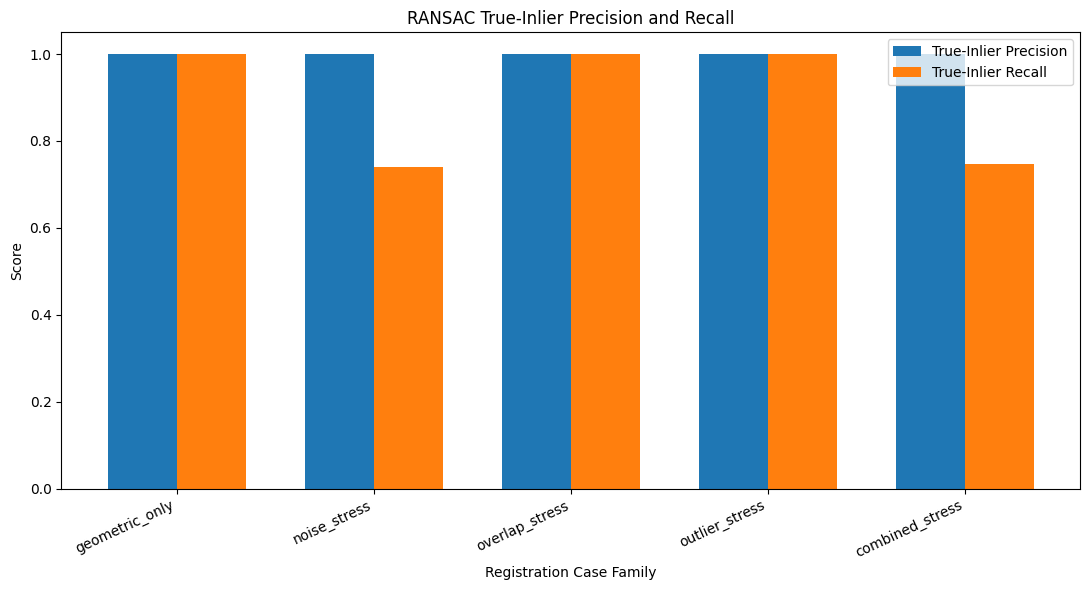

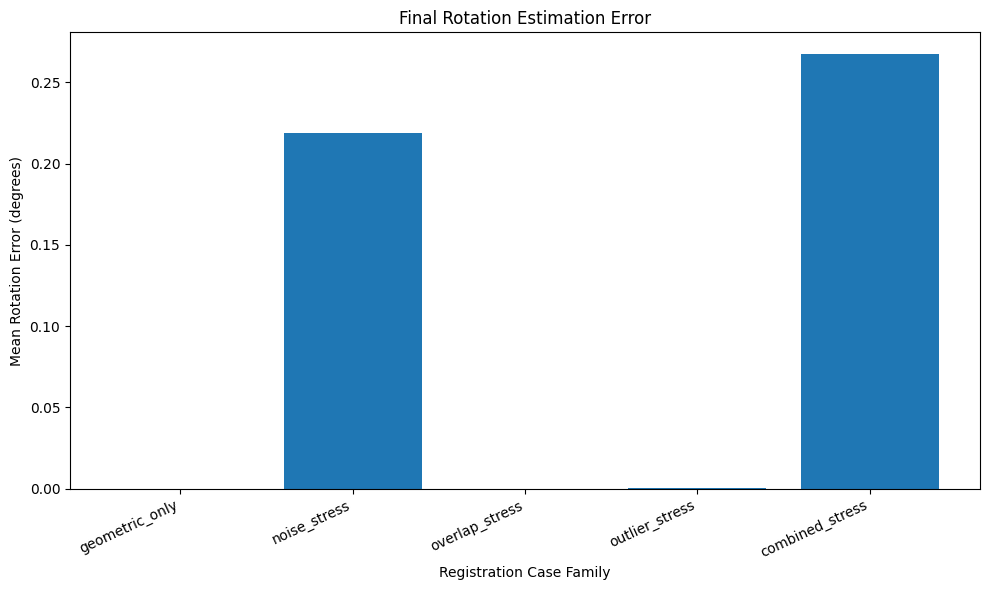

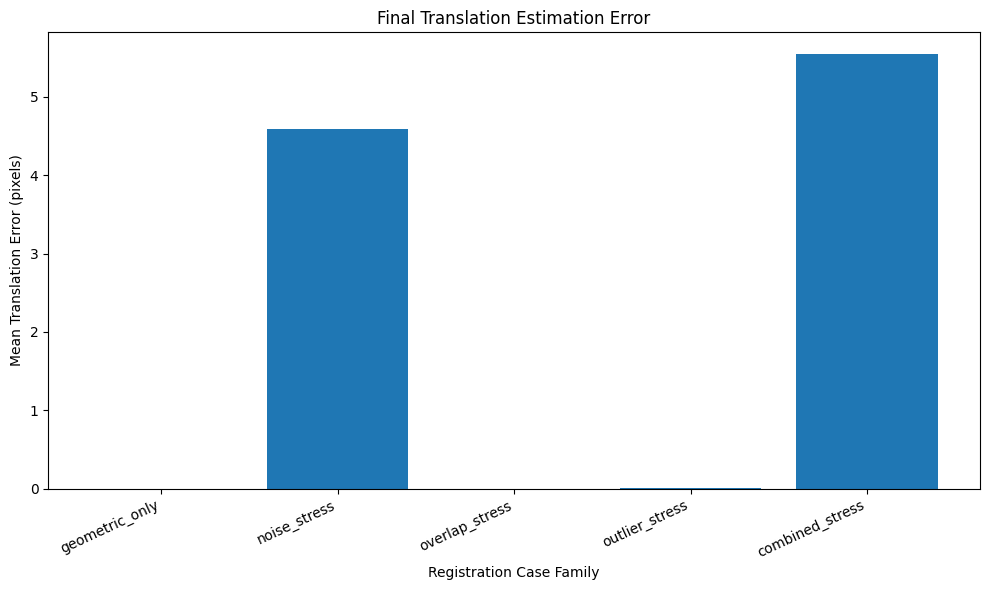


FINAL REGISTRATION BENCHMARK SUMMARY
Selected RANSAC threshold : 12.0 px
Registration cases       : 2000
Overall success rate     : 0.8225
Mean inlier-only RMSE    : 1.9531 px
Mean inlier ratio        : 0.7764
True-inlier precision    : 0.9998
True-inlier recall       : 0.8973
Mean rotation error      : 0.0973 deg
Mean scale error         : 0.001592
Mean translation error   : 2.0290 px

FAMILY-LEVEL RESULTS
      case_type  cases  success_rate  median_inlier_rmse  mean_inlier_ratio  mean_true_inlier_precision  mean_true_inlier_recall  mean_rotation_error_deg  mean_scale_error  mean_translation_error
 geometric_only    400        1.0000            0.000003           1.000000                    1.000000                 1.000000             2.579574e-07      3.995965e-09                0.000004
   noise_stress    400        0.7375            5.385058           0.739575                    1.000000                 0.739575             2.186444e-01      3.438376e-03                4.595646


In [10]:
# =============================================================================
# CELL 7 — FINAL REGISTRATION ROBUSTNESS VISUALIZATION
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("FINAL REGISTRATION ROBUSTNESS VISUALIZATION")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Load final selected-threshold results
# -----------------------------------------------------------------------------

if not os.path.exists(
    BEST_RESULTS_PATH
):
    raise FileNotFoundError(
        "Final registration results not found:\n"
        f"{BEST_RESULTS_PATH}\n\n"
        "Run Cell 6 first."
    )

if not os.path.exists(
    BEST_FAMILY_SUMMARY_PATH
):
    raise FileNotFoundError(
        "Final family summary not found:\n"
        f"{BEST_FAMILY_SUMMARY_PATH}\n\n"
        "Run Cell 6 first."
    )

if not os.path.exists(
    FINAL_SUMMARY_PATH
):
    raise FileNotFoundError(
        "Final summary not found:\n"
        f"{FINAL_SUMMARY_PATH}\n\n"
        "Run Cell 6 first."
    )

final_results = pd.read_csv(
    BEST_RESULTS_PATH
)

final_family_summary = pd.read_csv(
    BEST_FAMILY_SUMMARY_PATH
)

final_summary = pd.read_csv(
    FINAL_SUMMARY_PATH
)

# -----------------------------------------------------------------------------
# 2. Create ordered family labels
# -----------------------------------------------------------------------------

family_order = [
    "geometric_only",
    "noise_stress",
    "overlap_stress",
    "outlier_stress",
    "combined_stress",
]

final_family_summary["case_type"] = pd.Categorical(
    final_family_summary["case_type"],
    categories=family_order,
    ordered=True
)

final_family_summary = (
    final_family_summary
    .sort_values("case_type")
    .reset_index(drop=True)
)

# -----------------------------------------------------------------------------
# 3. Plot — Success rate by case family
# -----------------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    final_family_summary["case_type"],
    final_family_summary["success_rate"]
)

plt.xlabel(
    "Registration Case Family"
)

plt.ylabel(
    "Success Rate"
)

plt.title(
    "Final RANSAC Registration Success by Case Family"
)

plt.ylim(
    0.0,
    1.05
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

FINAL_FAMILY_SUCCESS_FIG = os.path.join(
    FIGURES_DIR,
    "final_registration_success_by_family.png"
)

plt.savefig(
    FINAL_FAMILY_SUCCESS_FIG,
    dpi=250,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 4. Plot — Inlier-only RMSE by case family
# -----------------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    final_family_summary["case_type"],
    final_family_summary[
        "median_inlier_rmse"
    ]
)

plt.xlabel(
    "Registration Case Family"
)

plt.ylabel(
    "Median Inlier RMSE (pixels)"
)

plt.title(
    "Final Inlier-Only Registration RMSE by Case Family"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

FINAL_INLIER_RMSE_FIG = os.path.join(
    FIGURES_DIR,
    "final_inlier_rmse_by_family.png"
)

plt.savefig(
    FINAL_INLIER_RMSE_FIG,
    dpi=250,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 5. Plot — Inlier ratio by case family
# -----------------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    final_family_summary["case_type"],
    final_family_summary[
        "mean_inlier_ratio"
    ]
)

plt.xlabel(
    "Registration Case Family"
)

plt.ylabel(
    "Mean Inlier Ratio"
)

plt.title(
    "Final RANSAC Inlier Ratio by Case Family"
)

plt.ylim(
    0.0,
    1.05
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

FINAL_INLIER_RATIO_FIG = os.path.join(
    FIGURES_DIR,
    "final_inlier_ratio_by_family.png"
)

plt.savefig(
    FINAL_INLIER_RATIO_FIG,
    dpi=250,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 6. Plot — True-inlier precision and recall
# -----------------------------------------------------------------------------

x = np.arange(
    len(final_family_summary)
)

width = 0.35

plt.figure(
    figsize=(11, 6)
)

plt.bar(
    x - width / 2,
    final_family_summary[
        "mean_true_inlier_precision"
    ],
    width,
    label="True-Inlier Precision"
)

plt.bar(
    x + width / 2,
    final_family_summary[
        "mean_true_inlier_recall"
    ],
    width,
    label="True-Inlier Recall"
)

plt.xlabel(
    "Registration Case Family"
)

plt.ylabel(
    "Score"
)

plt.title(
    "RANSAC True-Inlier Precision and Recall"
)

plt.xticks(
    x,
    final_family_summary[
        "case_type"
    ],
    rotation=25,
    ha="right"
)

plt.ylim(
    0.0,
    1.05
)

plt.legend()

plt.tight_layout()

FINAL_PRECISION_RECALL_FIG = os.path.join(
    FIGURES_DIR,
    "final_true_inlier_precision_recall.png"
)

plt.savefig(
    FINAL_PRECISION_RECALL_FIG,
    dpi=250,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 7. Plot — Rotation error by case family
# -----------------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    final_family_summary["case_type"],
    final_family_summary[
        "mean_rotation_error_deg"
    ]
)

plt.xlabel(
    "Registration Case Family"
)

plt.ylabel(
    "Mean Rotation Error (degrees)"
)

plt.title(
    "Final Rotation Estimation Error"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

FINAL_ROTATION_FIG = os.path.join(
    FIGURES_DIR,
    "final_rotation_error_by_family.png"
)

plt.savefig(
    FINAL_ROTATION_FIG,
    dpi=250,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 8. Plot — Translation error by case family
# -----------------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    final_family_summary["case_type"],
    final_family_summary[
        "mean_translation_error"
    ]
)

plt.xlabel(
    "Registration Case Family"
)

plt.ylabel(
    "Mean Translation Error (pixels)"
)

plt.title(
    "Final Translation Estimation Error"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

FINAL_TRANSLATION_FIG = os.path.join(
    FIGURES_DIR,
    "final_translation_error_by_family.png"
)

plt.savefig(
    FINAL_TRANSLATION_FIG,
    dpi=250,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 9. Create final robustness table
# -----------------------------------------------------------------------------

final_robustness_table = final_family_summary[
    [
        "case_type",
        "cases",
        "success_rate",
        "median_inlier_rmse",
        "mean_inlier_ratio",
        "mean_true_inlier_precision",
        "mean_true_inlier_recall",
        "mean_rotation_error_deg",
        "mean_scale_error",
        "mean_translation_error",
    ]
].copy()

FINAL_ROBUSTNESS_TABLE_PATH = os.path.join(
    RESULTS_DIR,
    "final_registration_robustness_table.csv"
)

final_robustness_table.to_csv(
    FINAL_ROBUSTNESS_TABLE_PATH,
    index=False
)

# -----------------------------------------------------------------------------
# 10. Create benchmark conclusion JSON
# -----------------------------------------------------------------------------

BENCHMARK_CONCLUSION_PATH = os.path.join(
    RESULTS_DIR,
    "registration_benchmark_conclusion.txt"
)

selected_threshold = float(
    final_summary.loc[
        0,
        "selected_ransac_threshold_px"
    ]
)

overall_success = float(
    final_summary.loc[
        0,
        "success_rate"
    ]
)

overall_inlier_rmse = float(
    final_summary.loc[
        0,
        "mean_inlier_rmse"
    ]
)

overall_inlier_ratio = float(
    final_summary.loc[
        0,
        "mean_inlier_ratio"
    ]
)

overall_precision = float(
    final_summary.loc[
        0,
        "mean_true_inlier_precision"
    ]
)

overall_recall = float(
    final_summary.loc[
        0,
        "mean_true_inlier_recall"
    ]
)

overall_rotation = float(
    final_summary.loc[
        0,
        "mean_rotation_error_deg"
    ]
)

overall_scale = float(
    final_summary.loc[
        0,
        "mean_scale_error"
    ]
)

overall_translation = float(
    final_summary.loc[
        0,
        "mean_translation_error"
    ]
)

with open(
    BENCHMARK_CONCLUSION_PATH,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "SYNTHETIC GEOMETRIC REGISTRATION BENCHMARK\n"
    )

    file.write(
        "=" * 70
        +
        "\n\n"
    )

    file.write(
        "Dataset\n"
    )

    file.write(
        f"Registration cases: "
        f"{len(final_results)}\n"
    )

    file.write(
        f"Selected RANSAC threshold: "
        f"{selected_threshold:.1f} px\n\n"
    )

    file.write(
        "Overall performance\n"
    )

    file.write(
        f"Registration success rate: "
        f"{overall_success:.4f}\n"
    )

    file.write(
        f"Mean inlier-only RMSE: "
        f"{overall_inlier_rmse:.4f} px\n"
    )

    file.write(
        f"Mean inlier ratio: "
        f"{overall_inlier_ratio:.4f}\n"
    )

    file.write(
        f"True-inlier precision: "
        f"{overall_precision:.4f}\n"
    )

    file.write(
        f"True-inlier recall: "
        f"{overall_recall:.4f}\n"
    )

    file.write(
        f"Mean rotation error: "
        f"{overall_rotation:.4f} deg\n"
    )

    file.write(
        f"Mean scale error: "
        f"{overall_scale:.6f}\n"
    )

    file.write(
        f"Mean translation error: "
        f"{overall_translation:.4f} px\n\n"
    )

    file.write(
        "Success criteria\n"
    )

    file.write(
        f"Inlier RMSE <= "
        f"{SUCCESS_MAX_RMSE_LOCAL:.1f} px\n"
    )

    file.write(
        f"Rotation error <= "
        f"{SUCCESS_MAX_ROTATION_ERROR_DEG_LOCAL:.1f} deg\n"
    )

    file.write(
        f"Scale error <= "
        f"{SUCCESS_MAX_SCALE_ERROR_LOCAL:.3f}\n"
    )

    file.write(
        f"Translation error <= "
        f"{SUCCESS_MAX_TRANSLATION_ERROR_LOCAL:.1f} px\n"
    )

    file.write(
        f"Inlier ratio >= "
        f"{SUCCESS_MIN_INLIER_RATIO_LOCAL:.2f}\n"
    )

    file.write(
        "\nInterpretation\n"
    )

    file.write(
        "This is a controlled synthetic geometric-registration "
        "benchmark using known ground-truth transformations. "
        "It demonstrates robustness of the correspondence-to-"
        "registration stage under geometric variation, localization "
        "noise, outliers, partial overlap, and combined stress. "
        "It does not constitute validation on real cross-modal "
        "OHRC/TMC-2/IIRS geographic correspondences.\n"
    )

# -----------------------------------------------------------------------------
# 11. Print final summary
# -----------------------------------------------------------------------------

print()
print("=" * 80)
print("FINAL REGISTRATION BENCHMARK SUMMARY")
print("=" * 80)

print(
    f"Selected RANSAC threshold : "
    f"{selected_threshold:.1f} px"
)

print(
    f"Registration cases       : "
    f"{len(final_results)}"
)

print(
    f"Overall success rate     : "
    f"{overall_success:.4f}"
)

print(
    f"Mean inlier-only RMSE    : "
    f"{overall_inlier_rmse:.4f} px"
)

print(
    f"Mean inlier ratio        : "
    f"{overall_inlier_ratio:.4f}"
)

print(
    f"True-inlier precision    : "
    f"{overall_precision:.4f}"
)

print(
    f"True-inlier recall       : "
    f"{overall_recall:.4f}"
)

print(
    f"Mean rotation error      : "
    f"{overall_rotation:.4f} deg"
)

print(
    f"Mean scale error         : "
    f"{overall_scale:.6f}"
)

print(
    f"Mean translation error   : "
    f"{overall_translation:.4f} px"
)

print()
print("=" * 80)
print("FAMILY-LEVEL RESULTS")
print("=" * 80)

print(
    final_robustness_table.to_string(
        index=False
    )
)

print()
print("=" * 80)
print("FINAL OUTPUTS")
print("=" * 80)

print(
    f"  {FINAL_ROBUSTNESS_TABLE_PATH}"
)

print(
    f"  {BENCHMARK_CONCLUSION_PATH}"
)

print(
    f"  {FINAL_FAMILY_SUCCESS_FIG}"
)

print(
    f"  {FINAL_INLIER_RMSE_FIG}"
)

print(
    f"  {FINAL_INLIER_RATIO_FIG}"
)

print(
    f"  {FINAL_PRECISION_RECALL_FIG}"
)

print(
    f"  {FINAL_ROTATION_FIG}"
)

print(
    f"  {FINAL_TRANSLATION_FIG}"
)

print()
print(
    "[OK] Final robustness tables generated."
)

print(
    "[OK] Inlier-only RMSE visualized."
)

print(
    "[OK] Inlier ratio visualized."
)

print(
    "[OK] Precision/recall visualized."
)

print(
    "[OK] Transformation errors visualized."
)

print(
    "[OK] Benchmark interpretation saved."
)

print("=" * 80)
print("CELL 7 COMPLETE")
print("=" * 80)

In [11]:
# =============================================================================
# CELL 8 — FINAL REGISTRATION BENCHMARK AUDIT AND FREEZE
# =============================================================================

import os
import json
import numpy as np
import pandas as pd

print("=" * 80)
print("FINAL REGISTRATION BENCHMARK AUDIT AND FREEZE")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Required output files
# -----------------------------------------------------------------------------

required_files = [
    OBSERVED_POINTS_PATH,
    GROUND_TRUTH_POINTS_PATH,
    GROUND_TRUTH_METADATA_PATH,
    RESULTS_PATH,
    THRESHOLD_RESULTS_PATH,
    THRESHOLD_SUMMARY_PATH,
    BEST_RESULTS_PATH,
    BEST_FAMILY_SUMMARY_PATH,
    FINAL_SUMMARY_PATH,
    FINAL_ROBUSTNESS_TABLE_PATH,
    BENCHMARK_CONCLUSION_PATH,
    FINAL_FAMILY_SUCCESS_FIG,
    FINAL_INLIER_RMSE_FIG,
    FINAL_INLIER_RATIO_FIG,
    FINAL_PRECISION_RECALL_FIG,
    FINAL_ROTATION_FIG,
    FINAL_TRANSLATION_FIG,
]

missing_files = [
    path
    for path in required_files
    if not os.path.exists(path)
]

if len(missing_files) > 0:

    print()
    print("[ERROR] Missing required outputs:")

    for path in missing_files:
        print(
            f"  {path}"
        )

    raise FileNotFoundError(
        "Registration benchmark is not ready to freeze."
    )

print(
    f"[OK] All {len(required_files)} required outputs exist."
)

# -----------------------------------------------------------------------------
# 2. Load final results
# -----------------------------------------------------------------------------

final_results = pd.read_csv(
    BEST_RESULTS_PATH
)

final_summary = pd.read_csv(
    FINAL_SUMMARY_PATH
)

final_family_summary = pd.read_csv(
    BEST_FAMILY_SUMMARY_PATH
)

threshold_summary = pd.read_csv(
    THRESHOLD_SUMMARY_PATH
)

# -----------------------------------------------------------------------------
# 3. Verify final result dimensions
# -----------------------------------------------------------------------------

if len(final_results) != TOTAL_CASES:

    raise ValueError(
        "Final result count does not equal "
        f"TOTAL_CASES ({TOTAL_CASES})."
    )

if len(final_summary) != 1:

    raise ValueError(
        "Final summary must contain exactly one row."
    )

print(
    f"[OK] Final result rows: "
    f"{len(final_results)}"
)

# -----------------------------------------------------------------------------
# 4. Verify selected threshold
# -----------------------------------------------------------------------------

selected_threshold = float(
    final_summary.loc[
        0,
        "selected_ransac_threshold_px"
    ]
)

available_thresholds = (
    threshold_summary[
        "ransac_threshold_px"
    ]
    .astype(float)
    .tolist()
)

if selected_threshold not in (
    available_thresholds
):

    raise ValueError(
        "Selected RANSAC threshold was not evaluated."
    )

print(
    f"[OK] Selected RANSAC threshold: "
    f"{selected_threshold:.1f} px"
)

# -----------------------------------------------------------------------------
# 5. Verify case-family coverage
# -----------------------------------------------------------------------------

expected_families = set(
    REGISTRATION_CASE_TYPES
)

actual_families = set(
    final_family_summary[
        "case_type"
    ]
)

if actual_families != expected_families:

    raise ValueError(
        "Registration case-family coverage is incomplete."
    )

for family in REGISTRATION_CASE_TYPES:

    family_rows = final_results[
        final_results[
            "case_type"
        ]
        ==
        family
    ]

    if len(family_rows) != 400:

        raise ValueError(
            f"Family '{family}' does not contain "
            f"400 cases. Found {len(family_rows)}."
        )

print(
    "[OK] All 5 registration families contain 400 cases."
)

# -----------------------------------------------------------------------------
# 6. Verify finite metrics
# -----------------------------------------------------------------------------

metric_columns = [
    "inlier_rmse",
    "inlier_ratio",
    "true_inlier_precision",
    "true_inlier_recall",
    "rotation_error_deg",
    "scale_error",
    "translation_error",
]

for column in metric_columns:

    values = final_results[
        column
    ].to_numpy(
        dtype=np.float64
    )

    if not np.all(
        np.isfinite(values)
    ):

        raise ValueError(
            f"Non-finite values found in metric '{column}'."
        )

print(
    "[OK] All final registration metrics are finite."
)

# -----------------------------------------------------------------------------
# 7. Verify metric ranges
# -----------------------------------------------------------------------------

for column in [
    "inlier_ratio",
    "true_inlier_precision",
    "true_inlier_recall",
]:

    values = final_results[
        column
    ].to_numpy(
        dtype=np.float64
    )

    if np.any(
        values < 0.0
    ) or np.any(
        values > 1.0
    ):

        raise ValueError(
            f"Metric '{column}' is outside [0, 1]."
        )

print(
    "[OK] Inlier ratios and precision/recall values are valid."
)

# -----------------------------------------------------------------------------
# 8. Recalculate final metrics independently
# -----------------------------------------------------------------------------

recalculated_success_rate = float(
    final_results[
        "success"
    ].mean()
)

recalculated_mean_inlier_rmse = float(
    final_results[
        "inlier_rmse"
    ].mean()
)

recalculated_median_inlier_rmse = float(
    final_results[
        "inlier_rmse"
    ].median()
)

recalculated_mean_inlier_ratio = float(
    final_results[
        "inlier_ratio"
    ].mean()
)

recalculated_median_inlier_ratio = float(
    final_results[
        "inlier_ratio"
    ].median()
)

recalculated_precision = float(
    final_results[
        "true_inlier_precision"
    ].mean()
)

recalculated_recall = float(
    final_results[
        "true_inlier_recall"
    ].mean()
)

recalculated_rotation_error = float(
    final_results[
        "rotation_error_deg"
    ].mean()
)

recalculated_scale_error = float(
    final_results[
        "scale_error"
    ].mean()
)

recalculated_translation_error = float(
    final_results[
        "translation_error"
    ].mean()
)

# -----------------------------------------------------------------------------
# 9. Compare against saved summary
# -----------------------------------------------------------------------------

summary_checks = {
    "success_rate":
        (
            recalculated_success_rate,
            float(
                final_summary.loc[
                    0,
                    "success_rate"
                ]
            )
        ),

    "mean_inlier_rmse":
        (
            recalculated_mean_inlier_rmse,
            float(
                final_summary.loc[
                    0,
                    "mean_inlier_rmse"
                ]
            )
        ),

    "median_inlier_rmse":
        (
            recalculated_median_inlier_rmse,
            float(
                final_summary.loc[
                    0,
                    "median_inlier_rmse"
                ]
            )
        ),

    "mean_inlier_ratio":
        (
            recalculated_mean_inlier_ratio,
            float(
                final_summary.loc[
                    0,
                    "mean_inlier_ratio"
                ]
            )
        ),

    "median_inlier_ratio":
        (
            recalculated_median_inlier_ratio,
            float(
                final_summary.loc[
                    0,
                    "median_inlier_ratio"
                ]
            )
        ),

    "mean_true_inlier_precision":
        (
            recalculated_precision,
            float(
                final_summary.loc[
                    0,
                    "mean_true_inlier_precision"
                ]
            )
        ),

    "mean_true_inlier_recall":
        (
            recalculated_recall,
            float(
                final_summary.loc[
                    0,
                    "mean_true_inlier_recall"
                ]
            )
        ),

    "mean_rotation_error_deg":
        (
            recalculated_rotation_error,
            float(
                final_summary.loc[
                    0,
                    "mean_rotation_error_deg"
                ]
            )
        ),

    "mean_scale_error":
        (
            recalculated_scale_error,
            float(
                final_summary.loc[
                    0,
                    "mean_scale_error"
                ]
            )
        ),

    "mean_translation_error":
        (
            recalculated_translation_error,
            float(
                final_summary.loc[
                    0,
                    "mean_translation_error"
                ]
            )
        ),
}

for metric_name, (
    recalculated,
    saved
) in summary_checks.items():

    if not np.isclose(
        recalculated,
        saved,
        rtol=1e-8,
        atol=1e-8
    ):

        raise ValueError(
            f"Final summary mismatch for {metric_name}: "
            f"recalculated={recalculated}, "
            f"saved={saved}"
        )

print(
    "[OK] Saved final summary independently verified."
)

# -----------------------------------------------------------------------------
# 10. Verify success criteria
# -----------------------------------------------------------------------------

success_criteria = {
    "inlier_rmse_max_px":
        SUCCESS_MAX_RMSE_LOCAL,

    "rotation_error_max_deg":
        SUCCESS_MAX_ROTATION_ERROR_DEG_LOCAL,

    "scale_error_max":
        SUCCESS_MAX_SCALE_ERROR_LOCAL,

    "translation_error_max_px":
        SUCCESS_MAX_TRANSLATION_ERROR_LOCAL,

    "inlier_ratio_min":
        SUCCESS_MIN_INLIER_RATIO_LOCAL,
}

# -----------------------------------------------------------------------------
# 11. Verify every success label agrees with the criteria
# -----------------------------------------------------------------------------

recomputed_success = (
    (final_results["inlier_rmse"] <=
     SUCCESS_MAX_RMSE_LOCAL)

    &

    (final_results["rotation_error_deg"] <=
     SUCCESS_MAX_ROTATION_ERROR_DEG_LOCAL)

    &

    (final_results["scale_error"] <=
     SUCCESS_MAX_SCALE_ERROR_LOCAL)

    &

    (final_results["translation_error"] <=
     SUCCESS_MAX_TRANSLATION_ERROR_LOCAL)

    &

    (final_results["inlier_ratio"] >=
     SUCCESS_MIN_INLIER_RATIO_LOCAL)
)

if not np.array_equal(
    recomputed_success.to_numpy(
        dtype=bool
    ),
    final_results[
        "success"
    ].to_numpy(
        dtype=bool
    )
):

    raise ValueError(
        "Stored success labels do not agree "
        "with the stated success criteria."
    )

print(
    "[OK] All success/failure labels independently verified."
)

# -----------------------------------------------------------------------------
# 12. Create final machine-readable benchmark report
# -----------------------------------------------------------------------------

FINAL_REPORT_PATH = os.path.join(
    RESULTS_DIR,
    "registration_benchmark_final_report.json"
)

final_report = {
    "benchmark_name":
        "Synthetic Geometric Registration Benchmark",

    "benchmark_status":
        "FROZEN",

    "evaluation_type":
        "controlled_synthetic",

    "empirical_anchor_count":
        int(
            N_ANCHORS_REGISTRATION
        ),

    "registration_case_count":
        int(
            TOTAL_CASES
        ),

    "registration_case_families":
        REGISTRATION_CASE_TYPES,

    "points_per_full_case":
        int(
            POINTS_PER_CASE
        ),

    "selected_ransac_threshold_px":
        selected_threshold,

    "ransac_max_trials":
        int(
            RANSAC_MAX_TRIALS_LOCAL
        ),

    "ransac_confidence":
        float(
            RANSAC_CONFIDENCE_LOCAL
        ),

    "success_criteria":
        success_criteria,

    "overall_metrics":
        {
            "success_rate":
                recalculated_success_rate,

            "successful_cases":
                int(
                    final_results[
                        "success"
                    ].sum()
                ),

            "median_inlier_rmse_px":
                recalculated_median_inlier_rmse,

            "mean_inlier_rmse_px":
                recalculated_mean_inlier_rmse,

            "median_inlier_ratio":
                recalculated_median_inlier_ratio,

            "mean_inlier_ratio":
                recalculated_mean_inlier_ratio,

            "true_inlier_precision":
                recalculated_precision,

            "true_inlier_recall":
                recalculated_recall,

            "mean_rotation_error_deg":
                recalculated_rotation_error,

            "mean_scale_error":
                recalculated_scale_error,

            "mean_translation_error_px":
                recalculated_translation_error,
        },

    "interpretation":
        (
            "The benchmark evaluates controlled synthetic "
            "2-D geometric registration using known ground-truth "
            "similarity transformations. It tests geometric "
            "variation, localization noise, partial overlap, "
            "outlier contamination, and combined stress. "
            "The benchmark demonstrates registration robustness "
            "under controlled conditions but is not a substitute "
            "for validation on real geographically overlapping "
            "cross-modal OHRC, TMC-2, and IIRS observations."
        ),
}

with open(
    FINAL_REPORT_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_report,
        file,
        indent=2
    )

print(
    f"[OK] Final JSON report saved:\n"
    f"  {FINAL_REPORT_PATH}"
)

# -----------------------------------------------------------------------------
# 13. Create final human-readable report
# -----------------------------------------------------------------------------

FINAL_TEXT_REPORT_PATH = os.path.join(
    RESULTS_DIR,
    "REGISTRATION_BENCHMARK_FINAL_REPORT.txt"
)

with open(
    FINAL_TEXT_REPORT_PATH,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "SYNTHETIC GEOMETRIC REGISTRATION BENCHMARK\n"
    )

    file.write(
        "=" * 80
        +
        "\n\n"
    )

    file.write(
        "STATUS: FROZEN\n\n"
    )

    file.write(
        "DATASET\n"
    )

    file.write(
        f"Empirical anchors: "
        f"{N_ANCHORS_REGISTRATION}\n"
    )

    file.write(
        f"Registration cases: "
        f"{TOTAL_CASES}\n"
    )

    file.write(
        "Case families: "
        +
        ", ".join(
            REGISTRATION_CASE_TYPES
        )
        +
        "\n"
    )

    file.write(
        f"Points per full case: "
        f"{POINTS_PER_CASE}\n\n"
    )

    file.write(
        "RANSAC CONFIGURATION\n"
    )

    file.write(
        f"Selected reprojection threshold: "
        f"{selected_threshold:.1f} px\n"
    )

    file.write(
        f"Maximum iterations: "
        f"{RANSAC_MAX_TRIALS_LOCAL}\n"
    )

    file.write(
        f"Confidence: "
        f"{RANSAC_CONFIDENCE_LOCAL}\n\n"
    )

    file.write(
        "FINAL PERFORMANCE\n"
    )

    file.write(
        f"Success rate: "
        f"{recalculated_success_rate:.4f}\n"
    )

    file.write(
        f"Successful cases: "
        f"{int(final_results['success'].sum())}\n"
    )

    file.write(
        f"Median inlier RMSE: "
        f"{recalculated_median_inlier_rmse:.4f} px\n"
    )

    file.write(
        f"Mean inlier RMSE: "
        f"{recalculated_mean_inlier_rmse:.4f} px\n"
    )

    file.write(
        f"Median inlier ratio: "
        f"{recalculated_median_inlier_ratio:.4f}\n"
    )

    file.write(
        f"Mean inlier ratio: "
        f"{recalculated_mean_inlier_ratio:.4f}\n"
    )

    file.write(
        f"True-inlier precision: "
        f"{recalculated_precision:.4f}\n"
    )

    file.write(
        f"True-inlier recall: "
        f"{recalculated_recall:.4f}\n"
    )

    file.write(
        f"Mean rotation error: "
        f"{recalculated_rotation_error:.4f} deg\n"
    )

    file.write(
        f"Mean scale error: "
        f"{recalculated_scale_error:.6f}\n"
    )

    file.write(
        f"Mean translation error: "
        f"{recalculated_translation_error:.4f} px\n\n"
    )

    file.write(
        "SUCCESS CRITERIA\n"
    )

    file.write(
        f"Inlier RMSE <= "
        f"{SUCCESS_MAX_RMSE_LOCAL:.1f} px\n"
    )

    file.write(
        f"Rotation error <= "
        f"{SUCCESS_MAX_ROTATION_ERROR_DEG_LOCAL:.1f} deg\n"
    )

    file.write(
        f"Scale error <= "
        f"{SUCCESS_MAX_SCALE_ERROR_LOCAL:.3f}\n"
    )

    file.write(
        f"Translation error <= "
        f"{SUCCESS_MAX_TRANSLATION_ERROR_LOCAL:.1f} px\n"
    )

    file.write(
        f"Inlier ratio >= "
        f"{SUCCESS_MIN_INLIER_RATIO_LOCAL:.2f}\n\n"
    )

    file.write(
        "SCIENTIFIC SCOPE\n"
    )

    file.write(
        "This is a controlled synthetic geometric-registration "
        "benchmark derived from empirical TMC-2 embedding anchors. "
        "It evaluates robustness to geometric variation, "
        "localization noise, partial overlap, outlier contamination, "
        "and combined stress. It does not establish real-world "
        "cross-modal registration accuracy because the current "
        "OHRC, TMC-2, and IIRS datasets do not contain confirmed "
        "geographically overlapping cross-modal correspondences.\n"
    )

print(
    f"[OK] Final human-readable report saved:\n"
    f"  {FINAL_TEXT_REPORT_PATH}"
)

# -----------------------------------------------------------------------------
# 14. Final audit output
# -----------------------------------------------------------------------------

print()
print("=" * 80)
print("REGISTRATION BENCHMARK — FINAL AUDIT")
print("=" * 80)

print(
    f"Status                    : FROZEN"
)

print(
    f"Empirical anchors         : "
    f"{N_ANCHORS_REGISTRATION}"
)

print(
    f"Registration cases        : "
    f"{TOTAL_CASES}"
)

print(
    f"Selected RANSAC threshold : "
    f"{selected_threshold:.1f} px"
)

print(
    f"Success rate              : "
    f"{recalculated_success_rate:.4f}"
)

print(
    f"Median inlier RMSE        : "
    f"{recalculated_median_inlier_rmse:.4f} px"
)

print(
    f"Mean inlier RMSE          : "
    f"{recalculated_mean_inlier_rmse:.4f} px"
)

print(
    f"Mean inlier ratio         : "
    f"{recalculated_mean_inlier_ratio:.4f}"
)

print(
    f"True-inlier precision     : "
    f"{recalculated_precision:.4f}"
)

print(
    f"True-inlier recall        : "
    f"{recalculated_recall:.4f}"
)

print(
    f"Mean rotation error       : "
    f"{recalculated_rotation_error:.4f} deg"
)

print(
    f"Mean scale error          : "
    f"{recalculated_scale_error:.6f}"
)

print(
    f"Mean translation error    : "
    f"{recalculated_translation_error:.4f} px"
)

print()
print(
    "[OK] Required files verified."
)

print(
    "[OK] Dataset dimensions verified."
)

print(
    "[OK] Case-family coverage verified."
)

print(
    "[OK] Metrics verified as finite."
)

print(
    "[OK] Final metrics independently recomputed."
)

print(
    "[OK] Success criteria independently verified."
)

print(
    "[OK] Machine-readable report saved."
)

print(
    "[OK] Human-readable report saved."
)

print(
    "[OK] REGISTRATION BENCHMARK FROZEN."
)

print("=" * 80)
print("CELL 8 COMPLETE")
print("=" * 80)

FINAL REGISTRATION BENCHMARK AUDIT AND FREEZE
[OK] All 17 required outputs exist.
[OK] Final result rows: 2000
[OK] Selected RANSAC threshold: 12.0 px
[OK] All 5 registration families contain 400 cases.
[OK] All final registration metrics are finite.
[OK] Inlier ratios and precision/recall values are valid.
[OK] Saved final summary independently verified.
[OK] All success/failure labels independently verified.
[OK] Final JSON report saved:
  D:\ISRO\Synthetic_Registration_Benchmark\results\registration_benchmark_final_report.json
[OK] Final human-readable report saved:
  D:\ISRO\Synthetic_Registration_Benchmark\results\REGISTRATION_BENCHMARK_FINAL_REPORT.txt

REGISTRATION BENCHMARK — FINAL AUDIT
Status                    : FROZEN
Empirical anchors         : 400
Registration cases        : 2000
Selected RANSAC threshold : 12.0 px
Success rate              : 0.8225
Median inlier RMSE        : 0.0000 px
Mean inlier RMSE          : 1.9531 px
Mean inlier ratio         : 0.7764
True-inlier p